# Exploratory Visual Analysis of Housing Prices

**Dataset:** `housing_data.csv`  
**Target:** `SalePrice`  
**Tools:** Python, Pandas, Matplotlib  

> **Project context**  
> A real estate analytics team wants a first visual report on historical house sales before moving to modelling. The goal is to understand the housing market, identify the most important price drivers, and prepare a clean visual summary that can be presented to a stakeholder.


## Table of Contents

1. [About the Problem and Relevant Columns](#about-the-problem-and-relevant-columns)  
2. [Data Loading and Quick Inspection](#data-loading-and-quick-inspection)  
3. [Sale Price: Market Shape and Distribution](#sale-price-market-shape-and-distribution)  
4. [Property Size and Space Analysis](#property-size-and-space-analysis)  
5. [Location and Neighborhood Analysis](#location-and-neighborhood-analysis)  
6. [Quality and Condition Analysis](#quality-and-condition-analysis)  
7. [Age, Renovation, and Time Effects](#age-renovation-and-time-effects)  
8. [Relationships and Outliers](#relationships-and-outliers)  
9. [Final Visual Summary](#final-visual-summary)  
10. [Class Practice Tasks](#class-practice-tasks)


## About the Problem and Relevant Columns

The dataset contains **1,460 housing records** and **81 columns**. Each row represents one property sale. The main objective is to understand what appears to influence `SalePrice` and how the housing market behaves across different property types, locations, sizes, and quality levels.

### Why this dataset works well for visual analysis

This dataset is suitable for a classroom EDA notebook because it contains:

- a clear target variable: `SalePrice`
- several numerical features for distribution and relationship analysis
- several categorical features for grouping and comparison
- location-based variables that support real estate storytelling
- quality and condition variables that make box plots and grouped comparisons meaningful
- age and renovation variables that support timeline-style reasoning

### Relevant columns for this analysis

**Target**
- `SalePrice`

**Location and market segment**
- `Neighborhood`, `MSZoning`, `LotConfig`, `LandContour`, `Condition1`, `Condition2`, `BldgType`

**Property size and space**
- `LotFrontage`, `LotArea`, `GrLivArea`, `TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF`, `GarageArea`, `GarageCars`, `MasVnrArea`

**Quality and condition**
- `OverallQual`, `OverallCond`, `ExterQual`, `ExterCond`, `KitchenQual`, `HeatingQC`, `GarageQual`, `GarageCond`, `FireplaceQu`, `BsmtQual`, `BsmtCond`

**Age, construction, and renovation**
- `YearBuilt`, `YearRemodAdd`, `YrSold`, `MoSold`

**Structure and style**
- `HouseStyle`, `Foundation`, `RoofStyle`, `Exterior1st`, `Exterior2nd`, `SaleCondition`, `SaleType`, `CentralAir`

**Columns to treat carefully**
- `Unnamed: 0` behaves like an index column and should not be used as a feature
- `Alley`, `MasVnrType`, `GarageYrBlt`, and `Electrical` contain missing values and may need handling later

### Story for the notebook

The notebook follows the work of a real estate analyst who has been asked to prepare an initial visual report. The report should explain the price distribution, identify the main property segments, compare important categories, and highlight unusual cases before any predictive modelling begins.

### Analysis focus

The notebook is organized around these questions:

- What does the housing market look like overall?
- Which property features show useful variation?
- Which neighborhoods and property types stand out?
- Which quality and size features appear linked to price?
- Which visual patterns should be investigated further?


In [69]:
! pip install matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
df = pd.read_csv("../Datasets/Lesson_04_Working_With_Pandas/Assisted_Practice_Dataset/housing_data.csv")
df.head()

,Unnamed: 0,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,SC60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,1,SC20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No,No,No,0,May,2007,WD,Normal,181500
2,2,SC60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,3,SC70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,4,SC60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No,No,No,0,Dec,2008,WD,Normal,250000


## Data Loading and Quick Inspection

Before plotting anything, it is important to check the data structure, feature types, and missing values.

### What should be checked here

- number of rows and columns
- column names
- numeric versus categorical features
- missing values
- duplicate or index-like columns
- obvious data quality issues

### Questions for analysis

1. How many observations and features are available?  
   **Hint:** Use `df.shape`.

2. Which columns are numerical and which are categorical?  
   **Hint:** Use `df.dtypes` or `df.select_dtypes()`.

3. Which columns have missing values?  
   **Hint:** Use `df.isna().sum().sort_values(ascending=False)`.

4. Does `Unnamed: 0` behave like a real feature?  
   **Hint:** Compare it with the row index idea; it usually should not be used in plots.

5. Which variables look most promising for the first round of visual analysis?  
   **Hint:** Prioritize `SalePrice`, `GrLivArea`, `OverallQual`, `Neighborhood`, `YearBuilt`, and `TotalBsmtSF`.


In [71]:
# Q1
df.shape

(1460, 81)

In [72]:
#q2
df.dtypes

Unnamed: 0         int64
MSSubClass           str
MSZoning             str
LotFrontage      float64
LotArea            int64
Street               str
Alley                str
LotShape             str
LandContour          str
Utilities            str
LotConfig            str
LandSlope            str
Neighborhood         str
Condition1           str
Condition2           str
BldgType             str
HouseStyle           str
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle            str
RoofMatl             str
Exterior1st          str
Exterior2nd          str
MasVnrType           str
MasVnrArea       float64
ExterQual            str
ExterCond            str
Foundation           str
BsmtQual             str
BsmtCond             str
BsmtExposure         str
BsmtFinType1         str
BsmtFinSF1         int64
BsmtFinType2         str
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating              str


In [73]:
# df.select_dtypes('object')
df.select_dtypes('object').head()

/var/folders/f7/6ttbslv14mb1smgbhyrcq1xh0000gn/T/ipykernel_20815/1724551348.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes('object').head()


,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,MoSold,SaleType,SaleCondition
0,SC60,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,No,Attchd,RFn,TA,TA,Y,No,No,No,Feb,WD,Normal
1,SC20,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,NaN,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,No,No,No,May,WD,Normal
2,SC60,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,No,No,No,Sep,WD,Normal
3,SC70,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,NaN,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,No,No,No,Feb,WD,Abnorml
4,SC60,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,No,No,No,Dec,WD,Normal


In [74]:
# df.select_dtypes('datetime')
df.select_dtypes('number').head()

,Unnamed: 0,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SalePrice
0,0,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2008,208500
1,1,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,2007,181500
2,2,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,2008,223500
3,3,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2006,140000
4,4,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,2008,250000


In [75]:
#3. Which columns have missing values?
df.isnull().sum()

Unnamed: 0          0
MSSubClass          0
MSZoning            0
LotFrontage         0
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          0
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual            0
BsmtCond            0
BsmtExposure        0
BsmtFinType1        0
BsmtFinSF1          0
BsmtFinType2        0
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [76]:
df.isnull().sum().sort_values(ascending=False)

Alley            1369
MasVnrType        872
GarageYrBlt        81
Electrical          1
KitchenAbvGr        0
GarageType          0
FireplaceQu         0
Fireplaces          0
Functional          0
TotRmsAbvGrd        0
KitchenQual         0
Unnamed: 0          0
GarageFinish        0
HalfBath            0
FullBath            0
BsmtHalfBath        0
BsmtFullBath        0
GrLivArea           0
LowQualFinSF        0
2ndFlrSF            0
BedroomAbvGr        0
GarageArea          0
GarageCars          0
PoolQC              0
SaleCondition       0
SaleType            0
YrSold              0
MoSold              0
MiscVal             0
MiscFeature         0
Fence               0
PoolArea            0
GarageQual          0
ScreenPorch         0
3SsnPorch           0
EnclosedPorch       0
OpenPorchSF         0
WoodDeckSF          0
PavedDrive          0
GarageCond          0
1stFlrSF            0
HeatingQC           0
CentralAir          0
LandSlope           0
OverallCond         0
OverallQua

In [77]:
# 4.Does Unnamed: 0 behave like a real feature?

df.columns

Index(['Unnamed: 0', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea',
       'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'Pa

In [78]:
df['Unnamed: 0']

0          0
1          1
2          2
3          3
4          4
5          5
6          6
7          7
8          8
9          9
10        10
11        11
12        12
13        13
14        14
15        15
16        16
17        17
18        18
19        19
20        20
21        21
22        22
23        23
24        24
25        25
26        26
27        27
28        28
29        29
30        30
31        31
32        32
33        33
34        34
35        35
36        36
37        37
38        38
39        39
40        40
41        41
42        42
43        43
44        44
45        45
46        46
47        47
48        48
49        49
50        50
51        51
52        52
53        53
54        54
55        55
56        56
57        57
58        58
59        59
60        60
61        61
62        62
63        63
64        64
65        65
66        66
67        67
68        68
69        69
70        70
71        71
72        72
73        73
74        74
75        75
76        76

In [79]:
# 5. Which variables look most promising for the first round of visual analysis?  
# Target variable: SalePrice
df.SalePrice.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [80]:
# Since Unnamed column behaves like Index and we already have index, therefore not required
df.drop(columns=['Unnamed: 0'], inplace=True)
# df.drop(columns=['Unnamed: 0','Alley','MasVnrType'], inplace=True)


In [81]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,SC60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,SC20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No,No,No,0,May,2007,WD,Normal,181500
2,SC60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,SC70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,SC60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No,No,No,0,Dec,2008,WD,Normal,250000


In [82]:
## Fill the Electrical and GarageYrBuilt columns
df.Electrical.value_counts()

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

In [83]:
# fill the Electrical with mode
df.Electrical.fillna(df.Electrical.mode()[0], inplace=True)

/var/folders/f7/6ttbslv14mb1smgbhyrcq1xh0000gn/T/ipykernel_20815/3604506139.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df.Electrical.fillna(df.Electrical.mode()[0], inplace=True)


0       SBrkr
1       SBrkr
2       SBrkr
3       SBrkr
4       SBrkr
5       SBrkr
6       SBrkr
7       SBrkr
8       FuseF
9       SBrkr
10      SBrkr
11      SBrkr
12      SBrkr
13      SBrkr
14      SBrkr
15      FuseA
16      SBrkr
17      SBrkr
18      SBrkr
19      SBrkr
20      SBrkr
21      FuseF
22      SBrkr
23      SBrkr
24      SBrkr
25      SBrkr
26      SBrkr
27      SBrkr
28      SBrkr
29      SBrkr
30      SBrkr
31      SBrkr
32      SBrkr
33      SBrkr
34      SBrkr
35      SBrkr
36      SBrkr
37      SBrkr
38      SBrkr
39      FuseP
40      SBrkr
41      SBrkr
42      SBrkr
43      SBrkr
44      FuseA
45      SBrkr
46      SBrkr
47      SBrkr
48      SBrkr
49      SBrkr
50      SBrkr
51      SBrkr
52      SBrkr
53      SBrkr
54      SBrkr
55      SBrkr
56      SBrkr
57      SBrkr
58      SBrkr
59      SBrkr
60      SBrkr
61      SBrkr
62      SBrkr
63      SBrkr
64      SBrkr
65      SBrkr
66      SBrkr
67      SBrkr
68      SBrkr
69      SBrkr
70      SBrkr
71    

In [84]:
# garage year built
df.GarageYrBlt.value_counts()

GarageYrBlt
2005.0    65
2006.0    59
2004.0    53
2003.0    50
2007.0    49
1977.0    35
1998.0    31
1999.0    30
1976.0    29
2008.0    29
2000.0    27
2002.0    26
1968.0    26
1950.0    24
1993.0    22
1965.0    21
1962.0    21
1958.0    21
1966.0    21
2009.0    21
2001.0    20
1970.0    20
1957.0    20
1996.0    20
1960.0    19
1954.0    19
1997.0    19
1978.0    19
1995.0    18
1964.0    18
1974.0    18
1994.0    18
1959.0    17
1963.0    16
1990.0    16
1956.0    16
1967.0    15
1979.0    15
1969.0    15
1980.0    15
1973.0    14
1920.0    14
1988.0    14
1972.0    14
1940.0    14
1961.0    13
1971.0    13
1955.0    13
1992.0    13
1953.0    12
1987.0    11
1948.0    11
1985.0    10
1981.0    10
1989.0    10
1925.0    10
1941.0    10
1939.0     9
1991.0     9
1975.0     9
1930.0     8
1984.0     8
1949.0     8
1983.0     7
1951.0     6
1926.0     6
1986.0     6
1936.0     5
1916.0     5
1922.0     5
1931.0     4
1935.0     4
1945.0     4
1982.0     4
1928.0     4
1946.0     4


In [85]:
# see all columns
pd.set_option('display.max_columns', None)

# see all rows
pd.set_option('display.max_rows', None)

In [86]:
# null rows of Garage Yr Built
df[df.GarageYrBlt.isnull()]


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
39,SC90,RL,65.0,6040,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,Duplex,1Story,4,5,1955,1955,Gable,CompShg,AsbShng,Plywood,NaN,0.0,TA,TA,PConc,No,No,No,No,0,No,0,0,0,GasA,TA,N,FuseP,1152,0,0,1152,0,0,2,0,2,2,Fa,6,Typ,0,No,No,NaN,No,0,0,No,No,N,0,0,0,0,0,0,No,No,No,0,Jun,2008,WD,AdjLand,82000
48,SC190,RM,33.0,4456,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,2fmCon,2Story,4,5,1920,2008,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,736,736,GasA,Gd,Y,SBrkr,736,716,0,1452,0,0,2,0,2,3,TA,8,Typ,0,No,No,NaN,No,0,0,No,No,N,0,0,102,0,0,0,No,No,No,0,Jun,2009,New,Partial,113000
78,SC90,RL,72.0,10778,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,Duplex,1Story,4,5,1968,1968,Hip,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0,Unf,0,1768,1768,GasA,TA,N,SBrkr,1768,0,0,1768,0,0,2,0,4,2,TA,8,Typ,0,No,No,NaN,No,0,0,No,No,Y,0,0,0,0,0,0,No,No,No,0,Apr,2010,WD,Normal,136500
88,SC50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,IDOTRR,Feedr,Feedr,1Fam,1.5Fin,3,2,1915,1982,Hip,CompShg,Plywood,Plywood,NaN,0.0,Fa,Fa,CBlock,TA,Fa,No,Unf,0,Unf,0,1013,1013,GasA,TA,N,SBrkr,1013,0,513,1526,0,0,1,0,2,1,Fa,6,Typ,0,No,No,NaN,No,0,0,No,No,N,0,0,156,0,0,0,No,MnPrv,No,0,Oct,2009,ConLD,Abnorml,85000
89,SC20,RL,60.0,8070,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,1Story,4,5,1994,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,588,Unf,0,402,990,GasA,Ex,Y,SBrkr,990,0,0,990,1,0,1,0,3,1,TA,5,Typ,0,No,No,NaN,No,0,0,No,No,Y,0,0,0,0,0,0,No,No,No,0,Aug,2007,WD,Normal,123600
99,SC20,RL,77.0,9320,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,4,5,1959,1959,Gable,CompShg,Plywood,Plywood,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,569,Unf,0,381,950,GasA,Fa,Y,SBrkr,1225,0,0,1225,1,0,1,1,3,1,TA,6,Typ,0,No,No,NaN,No,0,0,No,No,Y,352,0,0,0,0,0,No,No,Shed,400,Jan,2010,WD,Normal,128950
108,SC50,RM,85.0,8500,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,IDOTRR,Artery,Norm,1Fam,1.5Fin,5,7,1919,2005,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0,Unf,0,793,793,GasW,TA,N,FuseF,997,520,0,1517,0,0,2,0,3,1,Fa,7,Typ,0,No,No,NaN,No,0,0,No,No,N,0,0,144,0,0,0,No,No,No,0,Aug,2007,WD,Normal,115000
125,SC190,RM,60.0,6780,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,2fmCon,1.5Fin,6,8,1935,1982,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,Fa,CBlock,TA,TA,Av,GLQ,490,Unf,0,30,520,GasA,Gd,N,SBrkr,520,0,234,754,1,0,1,0,2,1,TA,5,Typ,0,No,No,NaN,No,0,0,No,No,N,53,0,0,0,0,0,No,No,No,0,Jun,2006,WD,Normal,84500
127,SC45,RM,55.0,4388,Pave,NaN,IR1,Bnk,AllPub,Inside,Gtl,OldTown,Feedr,Norm,1Fam,1.5Unf,5,7,1930,1950,Gable,CompShg,WdShing,Wd Sdng,NaN,0.0,TA,Gd,BrkTil,TA,TA,No,LwQ,116,Unf,0,556,672,GasA,Ex,Y,SBrkr,840,0,0,840,0,0,1,0,3,1,TA,5,Typ,1,TA,No,NaN,No,0,0,No,No,N,0,0,0,0,0,0,No,No,No,0,Jun,2007,WD,Normal,87000
140,SC20,RL,70.0,10500,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,NAmes,Norm,Norm,1Fam,1Story,4,5,1971,1971,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,432,Unf,0,432,864,GasA,TA,Y,SBrkr,864,0,0,864,0,0,1,0,3,1,TA,5,Typ,1,Po,No,NaN,No,0,0,No,No,Y,0,0,0,0,0,0,No,No,No,0,Apr,2010,ConLI,Normal,115000


In [87]:
# Fill the NaN with specific value like 0
df.GarageYrBlt.fillna(0, inplace=True)

/var/folders/f7/6ttbslv14mb1smgbhyrcq1xh0000gn/T/ipykernel_20815/2114357746.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df.GarageYrBlt.fillna(0, inplace=True)


0       2003.0
1       1976.0
2       2001.0
3       1998.0
4       2000.0
5       1993.0
6       2004.0
7       1973.0
8       1931.0
9       1939.0
10      1965.0
11      2005.0
12      1962.0
13      2006.0
14      1960.0
15      1991.0
16      1970.0
17      1967.0
18      2004.0
19      1958.0
20      2005.0
21      1930.0
22      2002.0
23      1976.0
24      1968.0
25      2007.0
26      2005.0
27      2008.0
28      1957.0
29      1920.0
30      1920.0
31      1966.0
32      2007.0
33      1959.0
34      2005.0
35      2004.0
36      1995.0
37      1954.0
38      1953.0
39         0.0
40      1965.0
41      1959.0
42      1983.0
43      1977.0
44      1959.0
45      2005.0
46      2003.0
47      2006.0
48         0.0
49      1966.0
50      1997.0
51      1985.0
52      1963.0
53      1981.0
54      1962.0
55      1964.0
56      1999.0
57      2004.0
58      2006.0
59      1973.0
60      2006.0
61      1935.0
62      2006.0
63      1990.0
64      1998.0
65      2004.0
66      19

In [88]:
df.isnull().sum().sort_values(ascending=False)

Alley            1369
MasVnrType        872
GarageYrBlt        81
Electrical          1
KitchenAbvGr        0
GarageType          0
FireplaceQu         0
Fireplaces          0
Functional          0
TotRmsAbvGrd        0
KitchenQual         0
MSSubClass          0
GarageFinish        0
HalfBath            0
FullBath            0
BsmtHalfBath        0
BsmtFullBath        0
GrLivArea           0
LowQualFinSF        0
2ndFlrSF            0
BedroomAbvGr        0
GarageArea          0
GarageCars          0
PoolQC              0
SaleCondition       0
SaleType            0
YrSold              0
MoSold              0
MiscVal             0
MiscFeature         0
Fence               0
PoolArea            0
GarageQual          0
ScreenPorch         0
3SsnPorch           0
EnclosedPorch       0
OpenPorchSF         0
WoodDeckSF          0
PavedDrive          0
GarageCond          0
1stFlrSF            0
CentralAir          0
MSZoning            0
Neighborhood        0
YearBuilt           0
OverallCon

In [89]:
df.duplicated().sum()

np.int64(0)

## Sale Price: Market Shape and Distribution

`SalePrice` is the target variable. Before comparing other features, the shape of the price distribution must be understood.

### What to look for

- common price range
- spread of the market
- skewness
- unusually expensive houses
- the difference between mean and median

### Questions for analysis

1. What is the overall distribution of `SalePrice`?  
   **Hint:** Use a **histogram** with a clear bin setting.

2. Is the sale price distribution symmetric or skewed?  
   **Hint:** Use the histogram shape and compare the left and right tails.

3. Are there extreme values in sale price?  
   **Hint:** Use a **box plot** to detect outliers.

4. Where do the mean and median fall in the price distribution?  
   **Hint:** Add reference lines on the histogram.

5. What does the distribution suggest about the market segment in this dataset?  
   **Hint:** Look for a long right tail or a concentrated middle band.


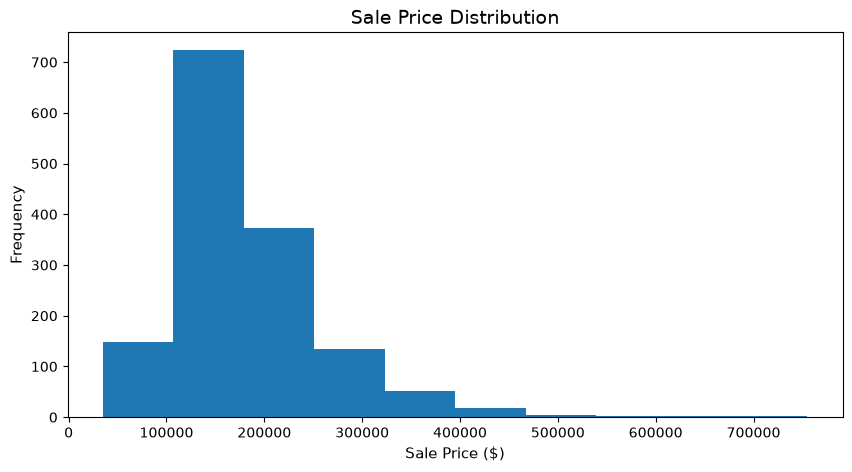

In [90]:
#1. What is the overall distribution of SalePrice?
plt.figure()

plt.hist(df.SalePrice)

plt.title('Sale Price Distribution')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')


plt.show()

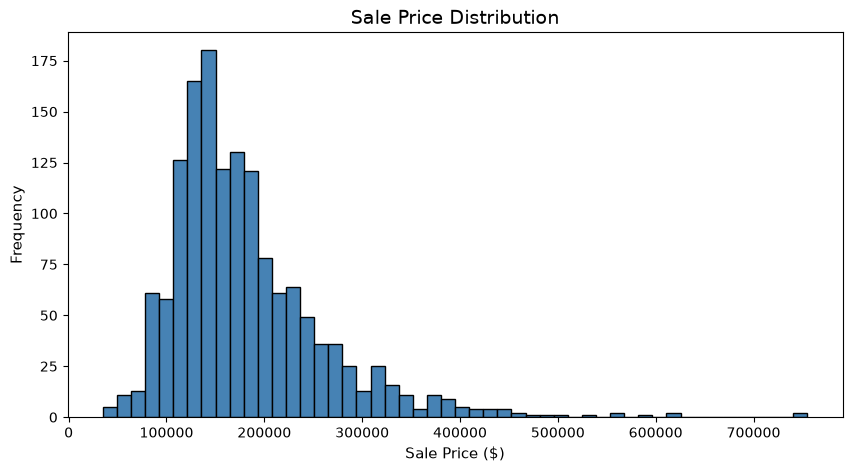

Skewness =  1.8828757597682129


In [91]:
# 2. Is the sale price distribution symmetric or skewed?

plt.figure(figsize=(10,5))
# n, bins, patches = plt.hist(df.SalePrice, bins=50, color='steelblue', edgecolor='black' )
plt.hist(df.SalePrice, bins=50, color='steelblue', edgecolor='black' )
plt.title('Sale Price Distribution')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')

# Calculate percentiles for annotation x-coordinates
left_tail_percentile = df.SalePrice.quantile(0.05)
right_tail_percentile = df.SalePrice.quantile(0.95)

# Determine appropriate y-coordinates for annotations
# max_freq = np.max(n)
# y_text_height = max_freq * 0.8 # y-coordinate for the annotation text
# y_arrow_point = max_freq * 0.05 # y-coordinate where the arrow points on the histogram

# # Calculate appropriate x-coordinates for the annotation text for correct pointing
# diff_percentiles = right_tail_percentile - left_tail_percentile
# xytext_left_x = left_tail_percentile + diff_percentiles * 0.1 # Text to the right of left tail
# xytext_right_x = right_tail_percentile - diff_percentiles * 0.1 # Text to the left of right tail

# # Annotate Short Left Tail
# plt.annotate(
#     "Short Left Tail",
#     xy=(left_tail_percentile, y_arrow_point),
#     xytext=(xytext_left_x, y_text_height),
#     arrowprops=dict(arrowstyle = '->', color = 'pink'),
#     fontsize = 11, color='Red'
# )

# # Annotate Long Right Tail
# plt.annotate(
#     "Long Right Tail",
#     xy=(right_tail_percentile, y_arrow_point),
#     xytext=(xytext_right_x, y_text_height),
#     arrowprops=dict(arrowstyle = '->', color = 'pink'),
#     fontsize = 11, color='Red'
# )

plt.show()

print("Skewness = ",df.SalePrice.skew())


/var/folders/f7/6ttbslv14mb1smgbhyrcq1xh0000gn/T/ipykernel_20815/2778742147.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df.SalePrice, vert=False, patch_artist = True)


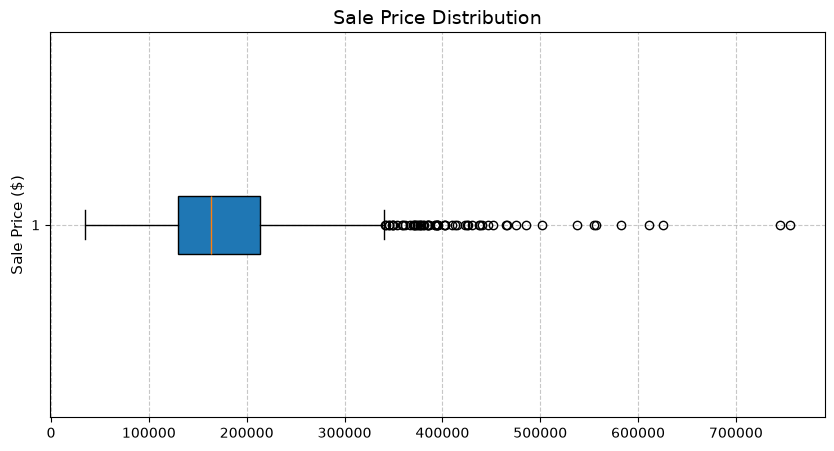

In [92]:
# 3. Are there extreme values in sale price?

plt.figure(figsize=(10,5))

plt.boxplot(df.SalePrice, vert=False, patch_artist = True)

plt.title('Sale Price Distribution')
plt.ylabel('Sale Price ($)')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
plt.show()

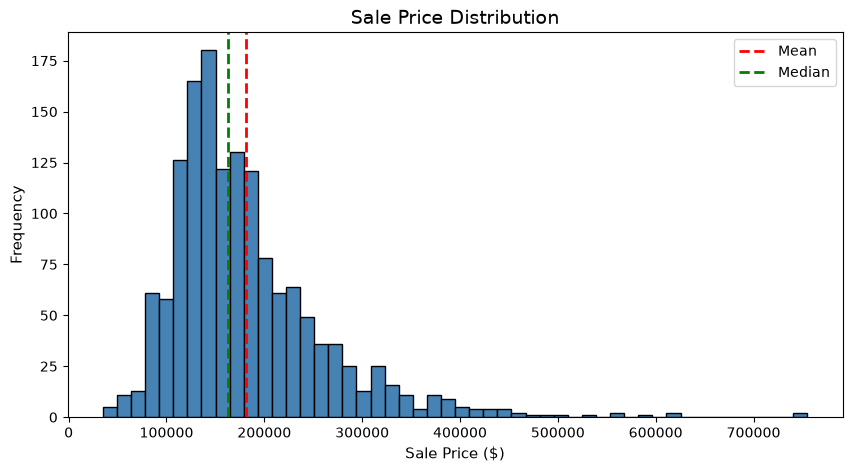

In [93]:
# 4. Where do the mean and median fall in the price distribution?

plt.figure(figsize=(10,5))

plt.hist(df.SalePrice, bins=50, color='steelblue', edgecolor='black' )

plt.axvline(df.SalePrice.mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df.SalePrice.median(), color='green', linestyle='dashed', linewidth=2, label='Median')




plt.title('Sale Price Distribution')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')

plt.legend()
plt.show()

In [94]:

#5. What does the distribution suggest about the market segment in this dataset?


### Observations on Sale Price Distribution

Based on the analysis of the `SalePrice` distribution:

*   **Skewness:** The distribution is highly **right-skewed**, as indicated by the histogram and a skewness value of approximately `1.88`. This means there is a longer tail on the higher price end, suggesting a presence of more expensive properties pulling the average up.
*   **Extreme Values/Outliers:** The box plot clearly shows a significant number of **outliers** on the higher end of the `SalePrice` spectrum. These represent homes sold at exceptionally high prices compared to the majority.
*   **Mean vs. Median:** Due to the right-skewness and the presence of high-value outliers, the **mean (`SalePrice` ~ 180,921)** is notably **higher than the median (`SalePrice` ~ 163,000)**. The median provides a better representation of the typical sale price in this market, as it is less affected by extreme values.
*   **Market Segment Suggestion:** The distribution suggests a market with a solid base of moderately priced homes, but also a distinct segment of high-value properties that significantly influence the overall average. This could indicate a diverse housing market catering to various income levels, with a luxury segment driving the upper tail.

## Property Size and Space Analysis

Property size is one of the first areas to examine in housing data. Larger homes often sell for more, but not every size measure has the same meaning.

### Features to compare

- `LotArea`
- `LotFrontage`
- `GrLivArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `2ndFlrSF`
- `GarageArea`
- `GarageCars`

### Questions for analysis

1. Does larger living area correspond to higher sale price?  
   **Hint:** Use a **scatter plot** of `GrLivArea` versus `SalePrice`.

2. Does lot size behave the same way as living area?  
   **Hint:** Compare `LotArea` with `SalePrice` using a **scatter plot**.

3. Does basement area appear related to sale price?  
   **Hint:** Use a **scatter plot** or a **small subplot panel** for size variables.

4. Do garage size and garage capacity show a visible price effect?  
   **Hint:** Compare `GarageArea` and `GarageCars` against `SalePrice`.

5. Which size feature appears most informative at first glance?  
   **Hint:** Place several scatter plots side by side and compare the pattern strength.

6. Are there unusually large homes with relatively low prices or small homes with unusually high prices?  
   **Hint:** Look for outliers in **scatter plots** and **box plots**.


In [95]:
# Relationship between GrLivArea and SalePrice
df[['GrLivArea', 'SalePrice']].describe()

,GrLivArea,SalePrice
count,1460.000000,1460.000000
mean,1515.463699,180921.195890
std,525.480383,79442.502883
min,334.000000,34900.000000
25%,1129.500000,129975.000000
50%,1464.000000,163000.000000
75%,1776.750000,214000.000000
max,5642.000000,755000.000000


In [96]:
# Corelation
df[['GrLivArea', 'SalePrice']].corr()

,GrLivArea,SalePrice
GrLivArea,1.000000,0.708624
SalePrice,0.708624,1.000000


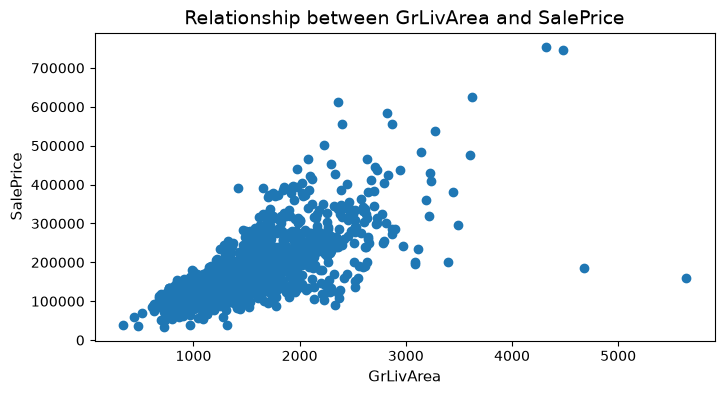

In [97]:
# scatter plot
plt.figure(figsize=(8,4))
plt.scatter(df.GrLivArea, df.SalePrice)

plt.title('Relationship between GrLivArea and SalePrice')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')

plt.show()

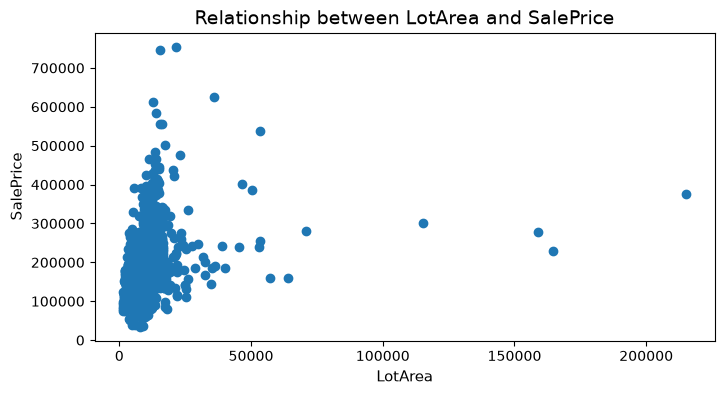

In [98]:

# 2. Does lot size behave the same way as living area?

plt.figure(figsize=(8,4))
plt.scatter(df.LotArea, df.SalePrice)

plt.title('Relationship between LotArea and SalePrice')
plt.xlabel('LotArea')
plt.ylabel('SalePrice')

plt.show()

In [99]:
df[['LotArea', 'SalePrice']].corr()


,LotArea,SalePrice
LotArea,1.000000,0.263843
SalePrice,0.263843,1.000000


In [100]:
# Does basement area appear related to sale price?
df[['TotalBsmtSF', 'SalePrice']].corr()


,TotalBsmtSF,SalePrice
TotalBsmtSF,1.000000,0.613581
SalePrice,0.613581,1.000000


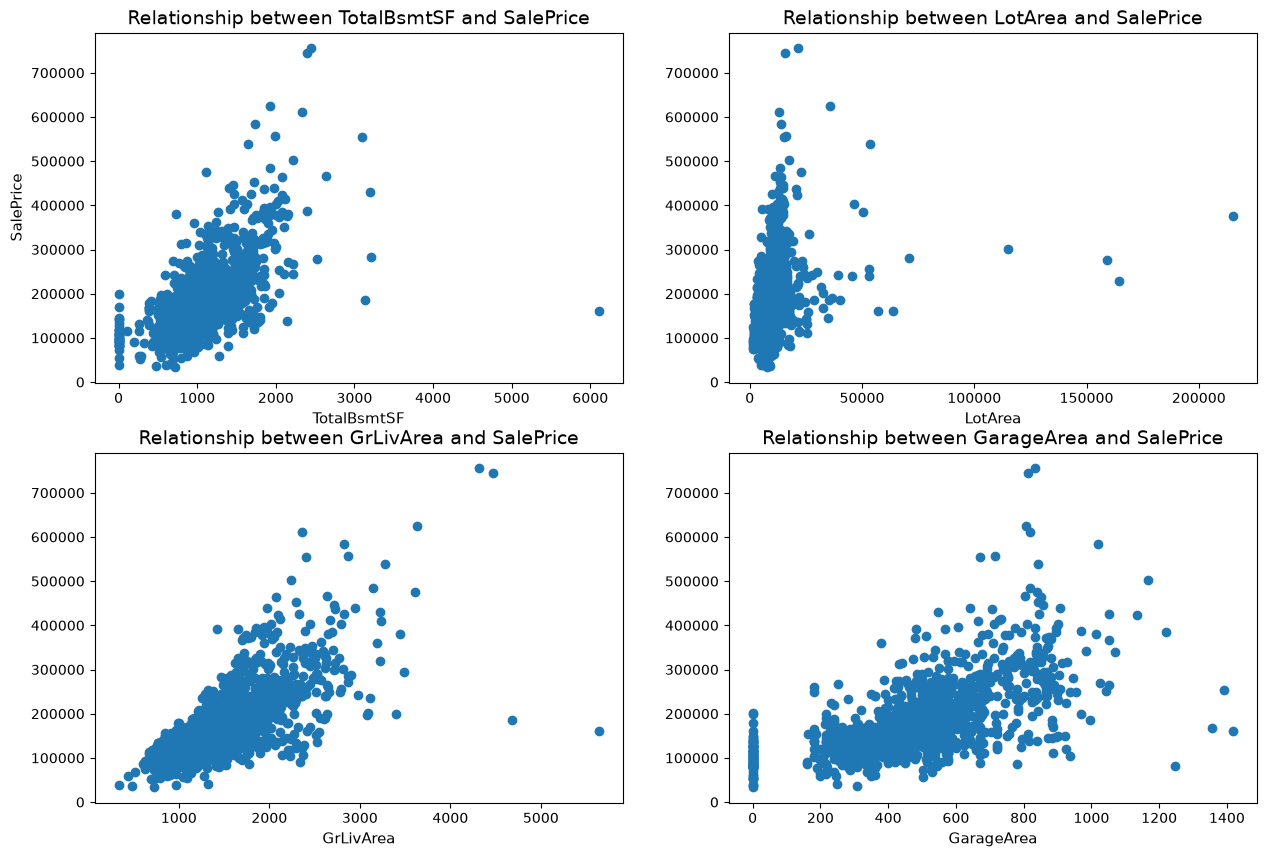

In [101]:
# Hint: Use a scatter plot or a small subplot panel for size variables.

# Sub-plot
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.scatter(df.TotalBsmtSF, df.SalePrice)
plt.title('Relationship between TotalBsmtSF and SalePrice')
plt.xlabel('TotalBsmtSF')
plt.ylabel('SalePrice')

plt.subplot(2,2,2)
plt.scatter(df.LotArea, df.SalePrice)
plt.title('Relationship between LotArea and SalePrice')
plt.xlabel('LotArea')

plt.subplot(2,2,3)
plt.scatter(df.GrLivArea, df.SalePrice)
plt.title('Relationship between GrLivArea and SalePrice')
plt.xlabel('GrLivArea')

plt.subplot(2,2,4)
plt.scatter(df.GarageArea, df.SalePrice)
plt.title('Relationship between GarageArea and SalePrice')
plt.xlabel('GarageArea')
plt.show()

In [102]:
# garage cars
df[['GarageArea', 'GarageCars', 'SalePrice']].corr()

,GarageArea,GarageCars,SalePrice
GarageArea,1.000000,0.882475,0.623431
GarageCars,0.882475,1.000000,0.640409
SalePrice,0.623431,0.640409,1.000000


In [103]:
# garage cars    #value_Counts return unique values and their counts in the GarageCars column
df.GarageCars.value_counts()

GarageCars
2    824
1    369
3    181
0     81
4      5
Name: count, dtype: int64

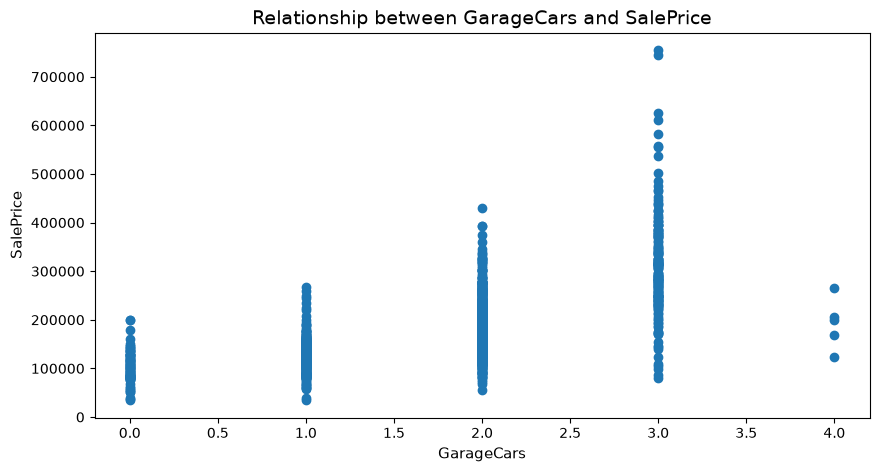

In [104]:
plt.scatter(df.GarageCars, df.SalePrice)
plt.title('Relationship between GarageCars and SalePrice')
plt.xlabel('GarageCars')
plt.ylabel('SalePrice')
plt.show()

In [105]:
# GarageCars vs SalePrice groupby
df.groupby('GarageCars').SalePrice.mean()

GarageCars
0    103317.283951
1    128116.688347
2    183851.663835
3    309636.121547
4    192655.800000
Name: SalePrice, dtype: float64

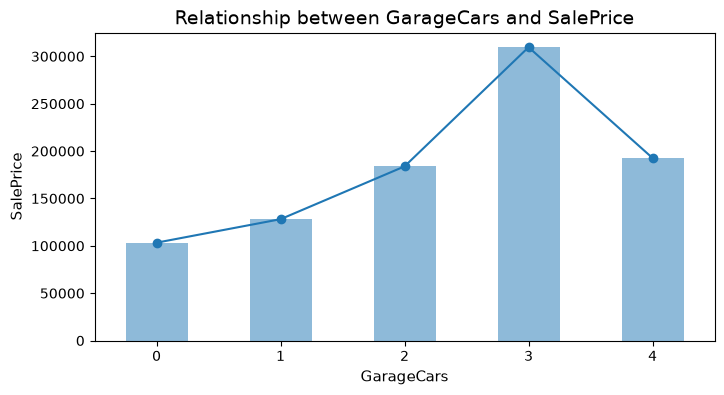

In [106]:
# graph of Bar Charts
plt.figure(figsize=(8,4))
df.groupby('GarageCars').SalePrice.mean().plot(kind='bar',alpha=0.5)
df.groupby('GarageCars').SalePrice.mean().plot(kind='line', marker = 'o')

plt.title('Relationship between GarageCars and SalePrice')
plt.xlabel('GarageCars')
plt.ylabel('SalePrice')
plt.show()

In [107]:
# 6. Are there unusually large homes with relatively low prices or small homes with unusually high prices?
lot_area_q1 = df.LotArea.quantile(0.25)
lot_area_q3 = df.LotArea.quantile(0.75)
lot_area_iqr = lot_area_q3 - lot_area_q1

lower_bound = lot_area_q1 - 1.5 * lot_area_iqr
upper_bound = lot_area_q3 + 1.5 * lot_area_iqr

# find the oultliers and saleprice of them
df_outliers = df[(df.LotArea < lower_bound) | (df.LotArea > upper_bound)]
df_outliers = df_outliers[['LotArea', 'SalePrice']]
print(df_outliers)

      LotArea  SalePrice
53      50271     385000
66      19900     180000
113     21000     217000
120     21453     180000
159     19378     320000
171     31770     215000
185     22950     475000
197     25419     235000
249    159000     277000
260     19296     176000
271     39104     241500
277     19138     141000
304     18386     295000
313    215245     375000
335    164660     228950
349     20431     437154
364     18800     190000
384     53107     240000
411     34650     145000
417     22420     239000
422     21750     113000
451     70761     280000
457     53227     256000
523     40094     184750
529     32668     200624
558     21872     175000
563     21780     185000
588     25095     143000
661     46589     402000
664     20896     423000
666     18450     129000
691     21535     755000
692     26178     335000
706    115149     302000
726     21695     222000
769     53504     538000
807     21384     223500
828     28698     185000
848     45600     240000


/var/folders/f7/6ttbslv14mb1smgbhyrcq1xh0000gn/T/ipykernel_20815/2652299161.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df.LotArea, vert=False, patch_artist = True)


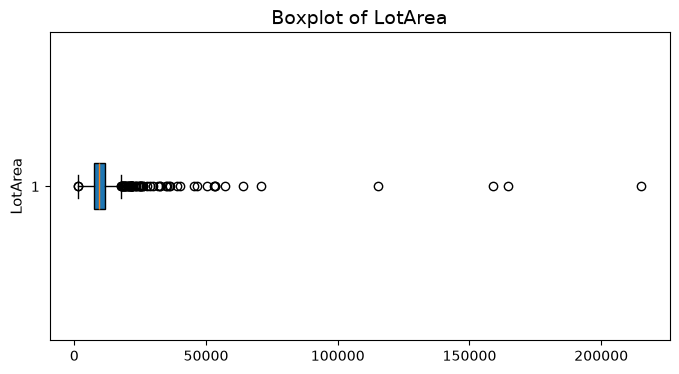

Lower Bound 1481.5
Upper Bound 17673.5
IQR 4048.0
Outliers 53       50271
66       19900
113      21000
120      21453
159      19378
171      31770
185      22950
197      25419
249     159000
260      19296
271      39104
277      19138
304      18386
313     215245
335     164660
349      20431
364      18800
384      53107
411      34650
417      22420
422      21750
451      70761
457      53227
523      40094
529      32668
558      21872
563      21780
588      25095
661      46589
664      20896
666      18450
691      21535
692      26178
706     115149
726      21695
769      53504
807      21384
828      28698
848      45600
854      17920
876      25286
934      27650
939      24090
943      25000
956       1300
1010     21286
1039      1477
1048     21750
1057     29959
1061     18000
1107     23257
1151     17755
1169     35760
1173     18030
1184     35133
1190     32463
1230     18890
1260     24682
1270     23595
1277     17871
1287     36500
1298     63887
1346     20

In [108]:
# 6. Are there unusually large homes with relatively low prices or small homes with unusually high prices?
lot_area_q1 = df.LotArea.quantile(0.25)
lot_area_q3 = df.LotArea.quantile(0.75)
lot_area_iqr = lot_area_q3 - lot_area_q1

lower_bound = lot_area_q1 - 1.5 * lot_area_iqr
upper_bound = lot_area_q3 + 1.5 * lot_area_iqr

# find the oultliers and saleprice of them
df_outliers = df[(df.LotArea < lower_bound) | (df.LotArea > upper_bound)]

#boxplot of lot area
plt.figure(figsize=(8,4))
plt.boxplot(df.LotArea, vert=False, patch_artist = True)
plt.title('Boxplot of LotArea')
plt.ylabel('LotArea')
plt.show()

print("Lower Bound", lower_bound)
print("Upper Bound", upper_bound)
print("IQR", lot_area_iqr)
print("Outliers", df_outliers.LotArea)

In [109]:
# corelation between outlier areas and price
df_outliers[['LotArea', 'SalePrice']].corr()

,LotArea,SalePrice
LotArea,1.000000,0.199763
SalePrice,0.199763,1.000000


Text(0, 0.5, 'SalePrice')

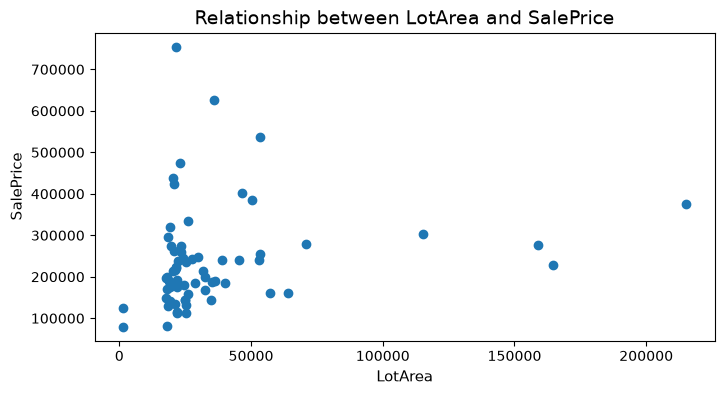

In [110]:
# plot it
plt.figure(figsize=(8,4))
plt.scatter(df_outliers.LotArea, df_outliers.SalePrice)
plt.title('Relationship between LotArea and SalePrice')
plt.xlabel('LotArea')
plt.ylabel('SalePrice')

### Observations on Property Size and Space Analysis

Based on the analysis of property size and space features in relation to `SalePrice`:

*   **`GrLivArea` (Above Grade Living Area):** This feature shows the strongest positive linear relationship with `SalePrice` (correlation coefficient of **0.71**). The scatter plot reveals a clear upward trend, indicating that larger living areas generally correspond to higher sale prices, with some high-value outliers.
*   **`TotalBsmtSF` (Total Basement Square Feet):** There is also a strong positive correlation between `TotalBsmtSF` and `SalePrice` (**0.61**). The scatter plot in the subplot panel reinforces this, showing that houses with larger basements tend to fetch higher prices.
*   **`GarageArea` and `GarageCars`:** Both `GarageArea` (correlation **0.62**) and `GarageCars` (correlation **0.64**) are strongly correlated with `SalePrice`. The bar chart for `GarageCars` shows a clear trend: as the number of cars a garage can hold increases from 0 to 3, the average sale price significantly rises. There's a slight drop for 4-car garages, but the overall pattern is strong.
*   **`LotArea` (Lot Size):** While `LotArea` has a positive correlation with `SalePrice` (**0.26**), it is considerably weaker than `GrLivArea` or garage-related features. The scatter plot for `LotArea` appears much more dispersed, and the box plot identified numerous outliers in lot area. The correlation with `SalePrice` for these outliers is even weaker (**0.19**), suggesting that extremely large lots don't necessarily guarantee a proportionally higher sale price, and the relationship is less straightforward.
*   **Outliers in `LotArea`:** The analysis identified several properties with unusually large `LotArea` values (outliers). Their `SalePrice` doesn't always scale proportionally, indicating that beyond a certain point, lot size has a diminishing impact on price, or other factors become more dominant.

In summary, `GrLivArea`, `TotalBsmtSF`, and garage capacity (`GarageCars`/`GarageArea`) are strong indicators of `SalePrice`, showing clear positive relationships. `LotArea`, while related, has a weaker and more dispersed relationship, with outliers not necessarily translating to significantly higher prices.


## Location and Neighborhood Analysis

Location is one of the strongest real estate factors. In this dataset, `Neighborhood` is the most useful location variable for first-pass analysis.

### What to compare

- sale price by neighborhood
- property counts by neighborhood
- zoning categories
- lot configuration
- land contour and slope

### Questions for analysis

1. Which neighborhoods contain the most properties?  
   **Hint:** Use a **horizontal bar chart** sorted by frequency.

2. Which neighborhoods have the highest typical sale prices?  
   **Hint:** Use a **box plot** of `SalePrice` grouped by `Neighborhood`.

3. Are expensive neighborhoods also rare in the dataset?  
   **Hint:** Compare a frequency chart with a price chart.

4. Do zoning categories show clear price differences?  
   **Hint:** Use a **bar chart** of average or median `SalePrice` by `MSZoning`.

5. Does the lot configuration seem connected to price patterns?  
   **Hint:** Use a **bar chart** or **box plot** for categorical comparison.

6. Which location variable gives the clearest business insight in one view?  
   **Hint:** Choose the chart that separates groups most clearly.


In [111]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [112]:
df.Neighborhood.value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

In [113]:
# Which neighborhoods contain the most properties?
neighborhood_counts = df.Neighborhood.value_counts().sort_values(ascending=False)
neighborhood_counts

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

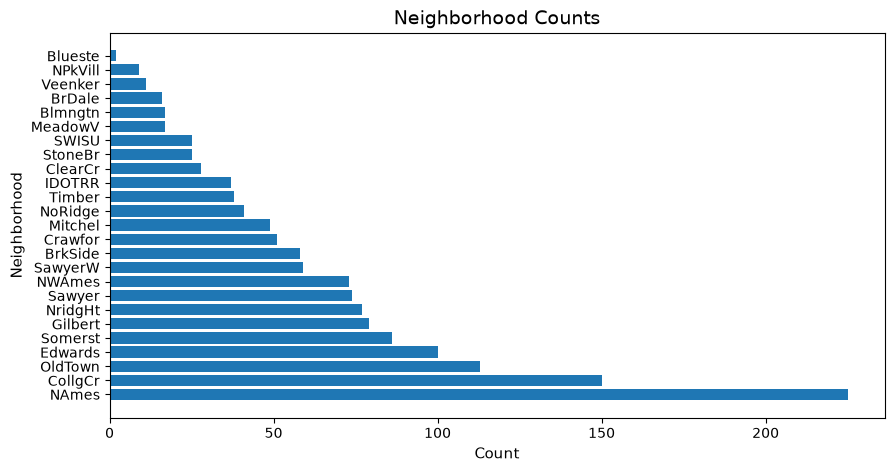

In [114]:
plt.figure(figsize=(10,5))

plt.barh(neighborhood_counts.index, neighborhood_counts)

plt.title('Neighborhood Counts')
plt.xlabel('Count')
plt.ylabel('Neighborhood')

plt.show()

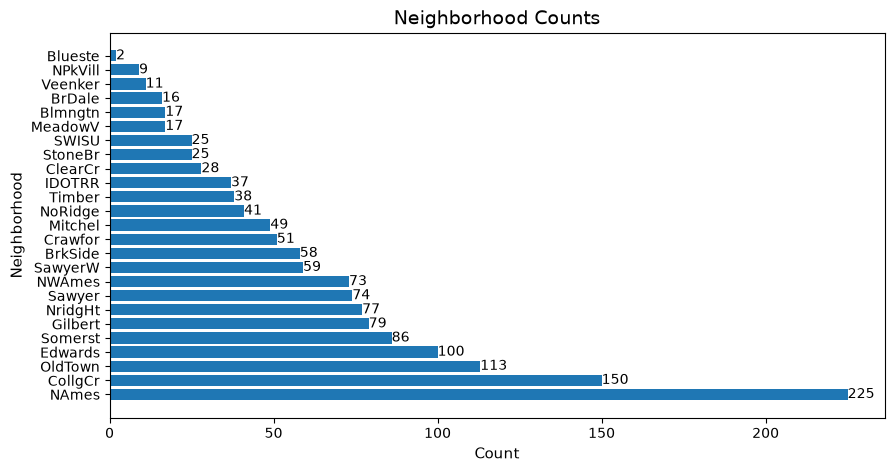

In [115]:
bars = plt.barh(neighborhood_counts.index, neighborhood_counts)
plt.bar_label(bars)

plt.title('Neighborhood Counts')
plt.xlabel('Count')
plt.ylabel('Neighborhood')

plt.show()

In [116]:
# Which neighborhoods have the highest typical sale prices?
# Hint: Use a box plot of SalePrice grouped by Neighborhood.
order = df.groupby('Neighborhood').SalePrice.median().sort_values(ascending=False)
order

Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Veenker    218000.0
Crawfor    200624.0
ClearCr    200250.0
CollgCr    197200.0
Blmngtn    191000.0
NWAmes     182900.0
Gilbert    181000.0
SawyerW    179900.0
Mitchel    153500.0
NPkVill    146000.0
NAmes      140000.0
SWISU      139500.0
Blueste    137500.0
Sawyer     135000.0
BrkSide    124300.0
Edwards    121750.0
OldTown    119000.0
BrDale     106000.0
IDOTRR     103000.0
MeadowV     88000.0
Name: SalePrice, dtype: float64

<Figure size 1400x1000 with 0 Axes>

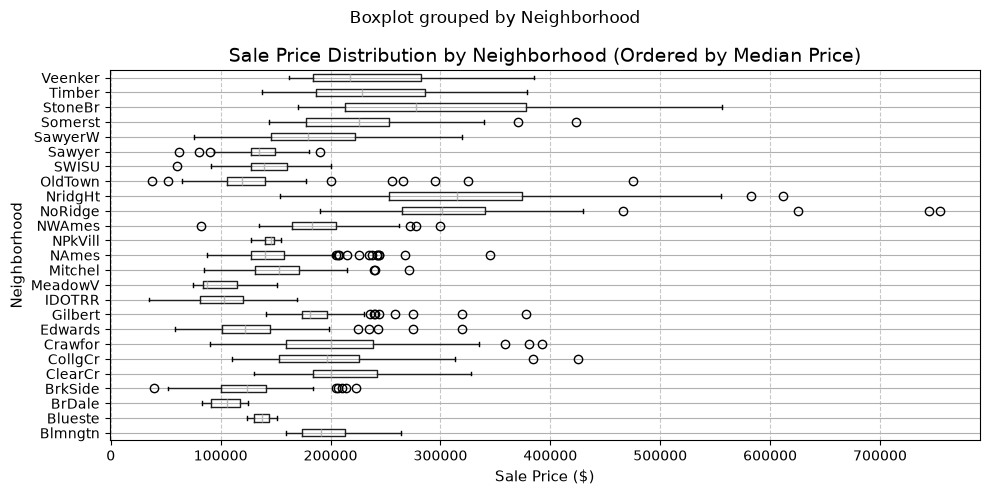

In [117]:
# Order neighborhoods by median SalePrice (highest to lowest)
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 10)) # Increased figure height for better readability
df.boxplot('SalePrice','Neighborhood', vert=False, positions=range(len(order)))

plt.title('Sale Price Distribution by Neighborhood (Ordered by Median Price)')
plt.xlabel('Sale Price ($)')
plt.ylabel('Neighborhood')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

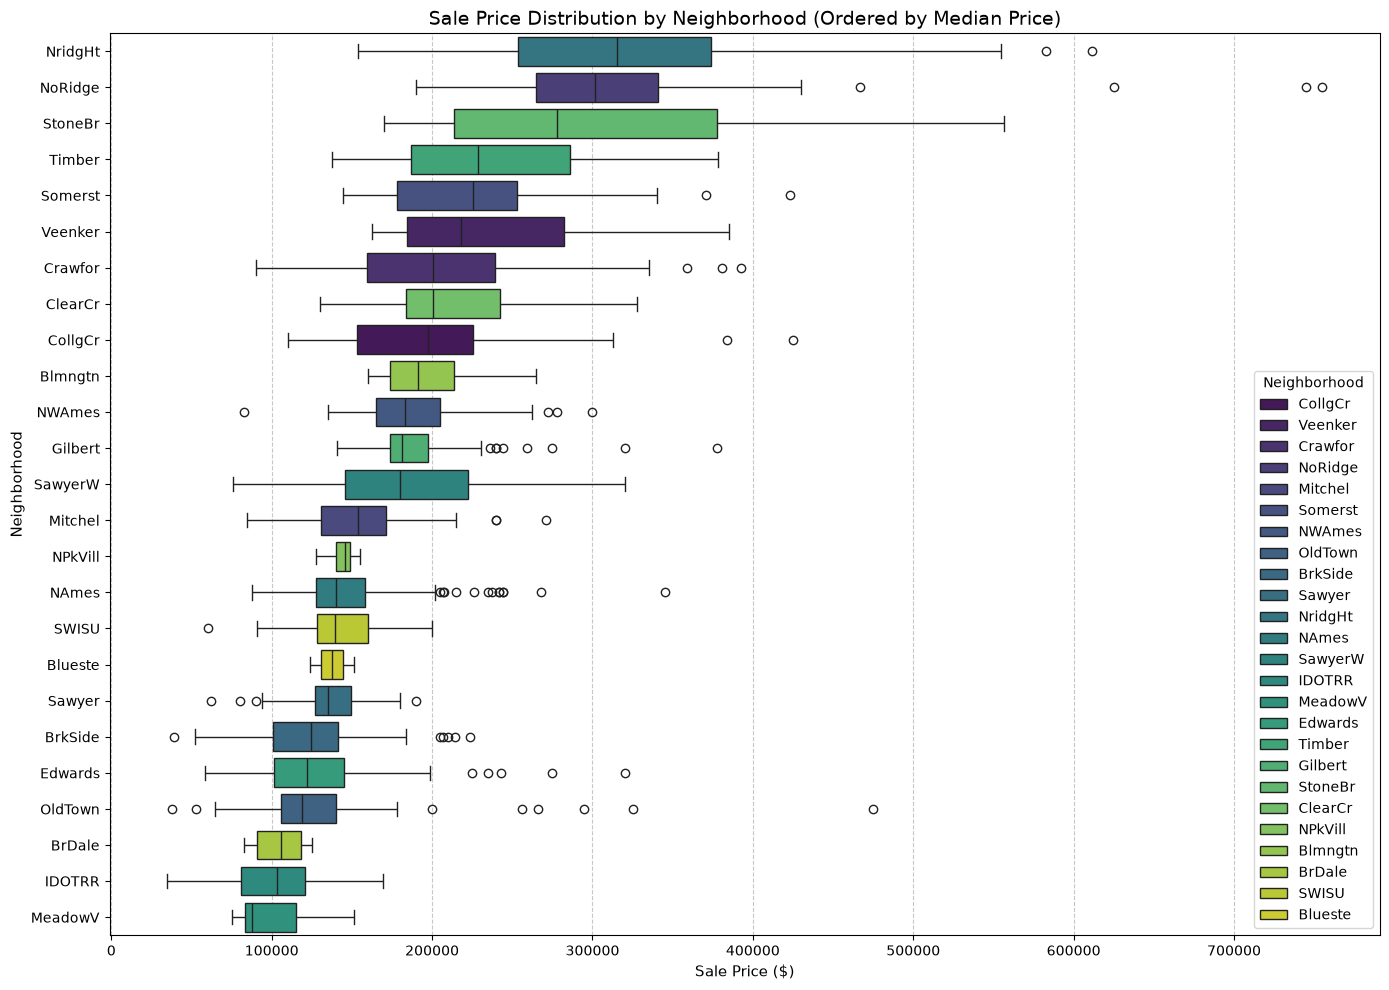

In [118]:
# Which neighborhoods have the highest typical sale prices?
# Hint: Use a box plot of SalePrice grouped by Neighborhood.

import seaborn as sns

# Order neighborhoods by median SalePrice (highest to lowest)
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 10)) # Increased figure height for better readability
sns.boxplot(x='SalePrice', y='Neighborhood', data=df, order=order, palette='viridis', hue='Neighborhood', legend=True)

plt.title('Sale Price Distribution by Neighborhood (Ordered by Median Price)')
plt.xlabel('Sale Price ($)')
plt.ylabel('Neighborhood')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

/var/folders/f7/6ttbslv14mb1smgbhyrcq1xh0000gn/T/ipykernel_20815/1478964603.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SalePrice', y='Neighborhood', data=df, order=order, palette='viridis')


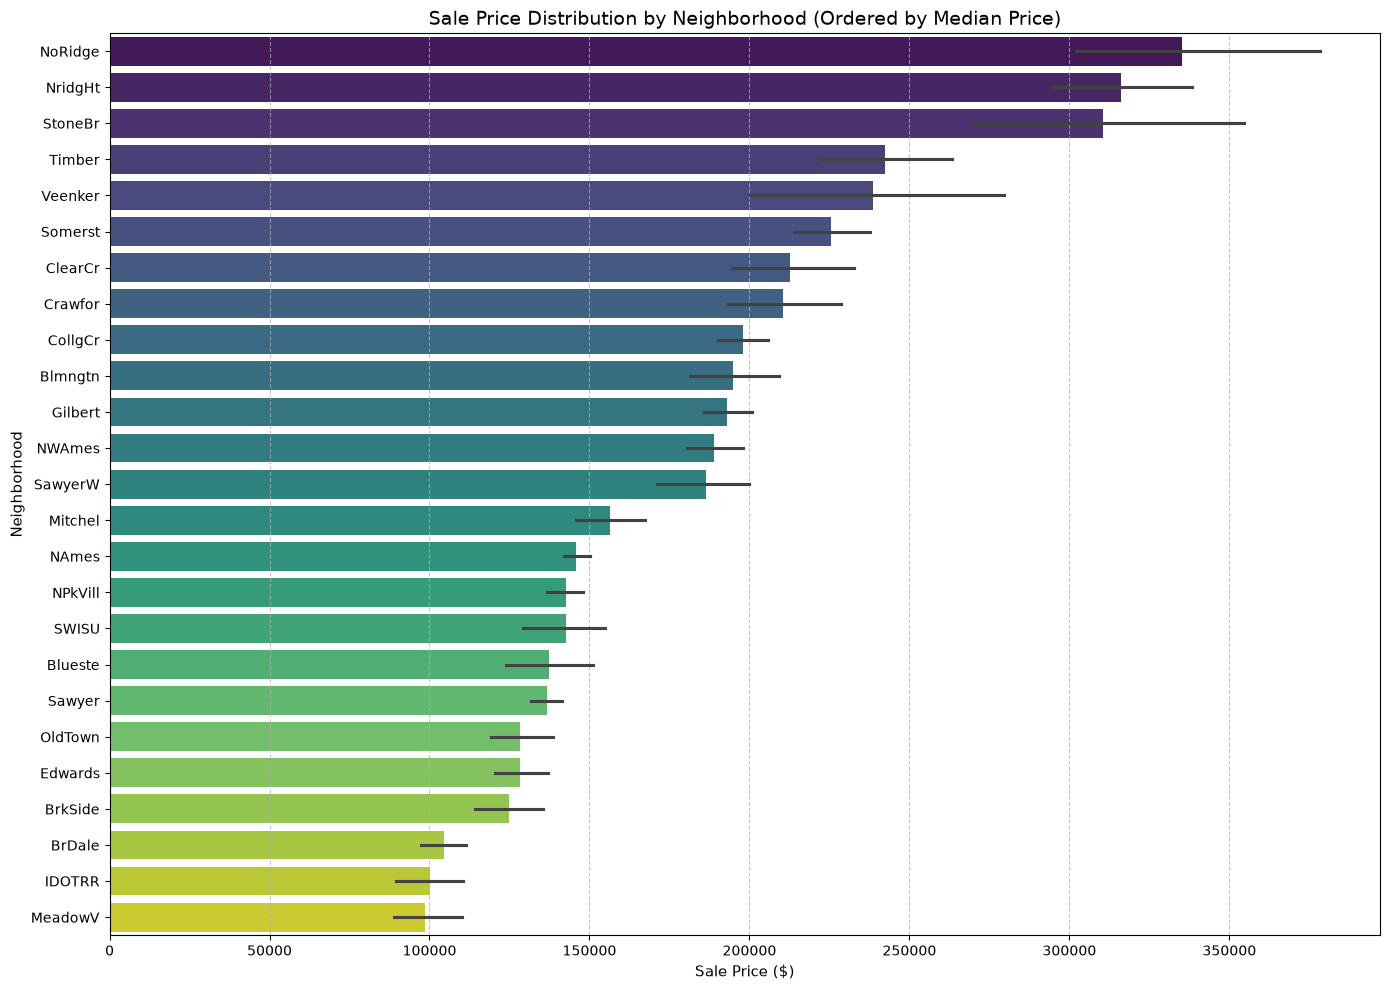

In [119]:
# Which neighborhoods have the highest typical sale prices?
# Hint: Use a box plot of SalePrice grouped by Neighborhood.

import seaborn as sns

# Order neighborhoods by median SalePrice (highest to lowest)
order = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).index

plt.figure(figsize=(14, 10)) # Increased figure height for better readability
sns.barplot(x='SalePrice', y='Neighborhood', data=df, order=order, palette='viridis')

plt.title('Sale Price Distribution by Neighborhood (Ordered by Median Price)')
plt.xlabel('Sale Price ($)')
plt.ylabel('Neighborhood')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Quality and Condition Analysis

Quality variables often explain price better than raw size alone. These features are useful for grouped comparison and box plot practice.

### Features to study

- `OverallQual`
- `OverallCond`
- `ExterQual`
- `ExterCond`
- `KitchenQual`
- `HeatingQC`
- `GarageQual`
- `GarageCond`
- `BsmtQual`
- `BsmtCond`
- `FireplaceQu`

### Questions for analysis

1. Does higher overall quality correspond to higher sale price?  
   **Hint:** Use a **box plot** of `SalePrice` by `OverallQual`.

2. Does overall condition follow the same pattern as overall quality?  
   **Hint:** Compare `OverallCond` with `OverallQual` using separate visuals.

3. Which quality feature appears most strongly related to price?  
   **Hint:** Use grouped **box plots** or **bar charts** for comparison.

4. Are higher quality homes also more consistent in price?  
   **Hint:** Check the spread within each quality group using a **box plot**.

5. Do kitchen quality and exterior quality show visible pricing tiers?  
   **Hint:** Use **box plots** grouped by category levels.

6. Which visual best communicates quality differences to a business audience?  
   **Hint:** Prefer the chart that shows both central tendency and spread.


In [120]:
columns = ['OverallCond',
'ExterQual',
'ExterCond',
'KitchenQual',
'HeatingQC',
'GarageQual',
'GarageCond',
'BsmtQual',
'BsmtCond',
'FireplaceQu']
for col in columns:
    print(df[col].value_counts())

OverallCond
5    821
6    252
7    205
8     72
4     57
3     25
9     22
2      5
1      1
Name: count, dtype: int64
ExterQual
TA    906
Gd    488
Ex     52
Fa     14
Name: count, dtype: int64
ExterCond
TA    1282
Gd     146
Fa      28
Ex       3
Po       1
Name: count, dtype: int64
KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64
HeatingQC
Ex    741
TA    428
Gd    241
Fa     49
Po      1
Name: count, dtype: int64
GarageQual
TA    1311
No      81
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64
GarageCond
TA    1326
No      81
Fa      35
Gd       9
Po       7
Ex       2
Name: count, dtype: int64
BsmtQual
TA    649
Gd    618
Ex    121
No     37
Fa     35
Name: count, dtype: int64
BsmtCond
TA    1311
Gd      65
Fa      45
No      37
Po       2
Name: count, dtype: int64
FireplaceQu
No    690
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64


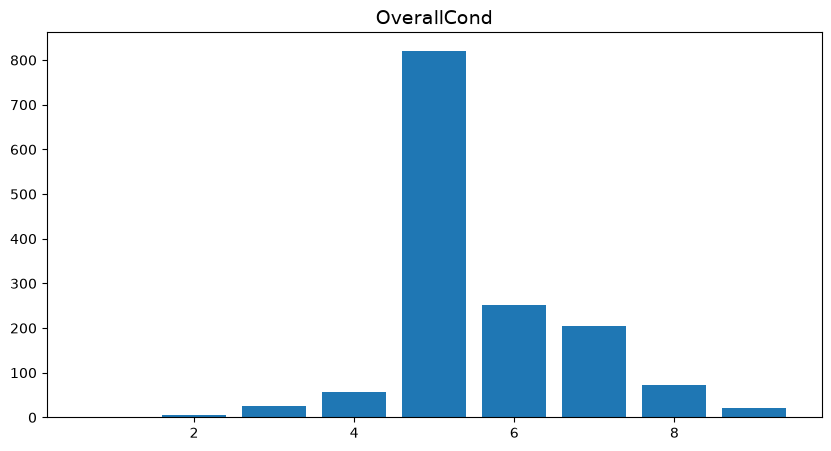

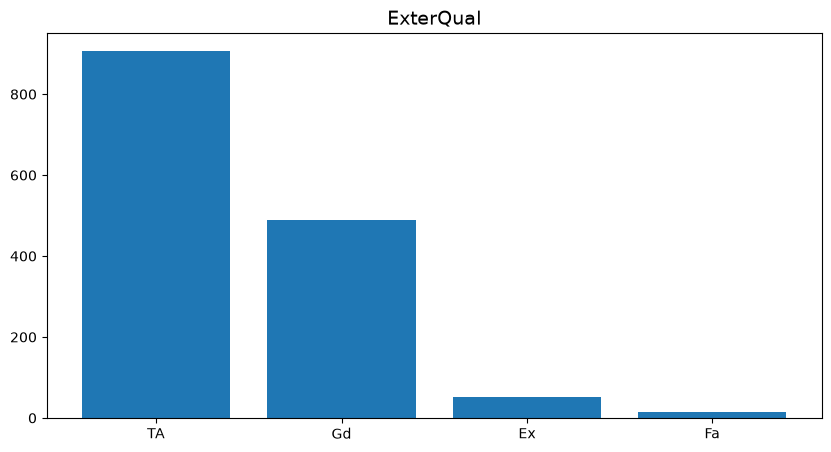

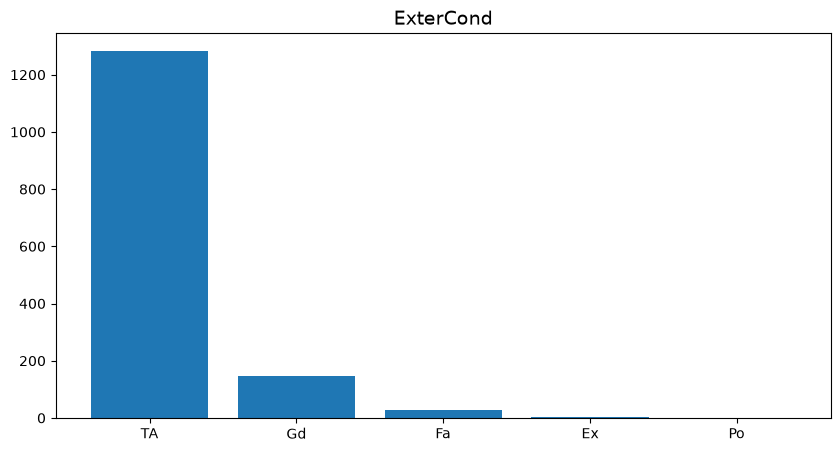

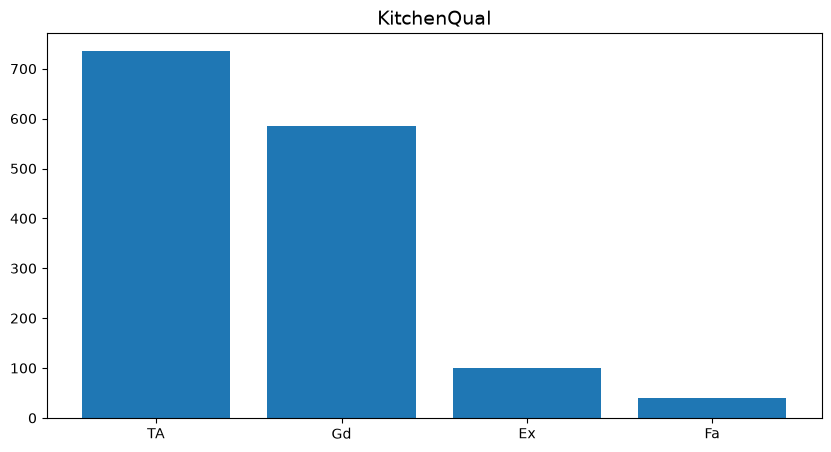

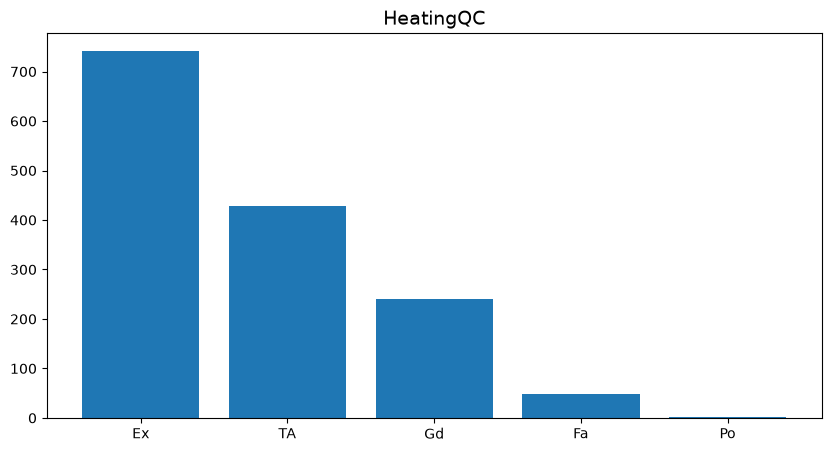

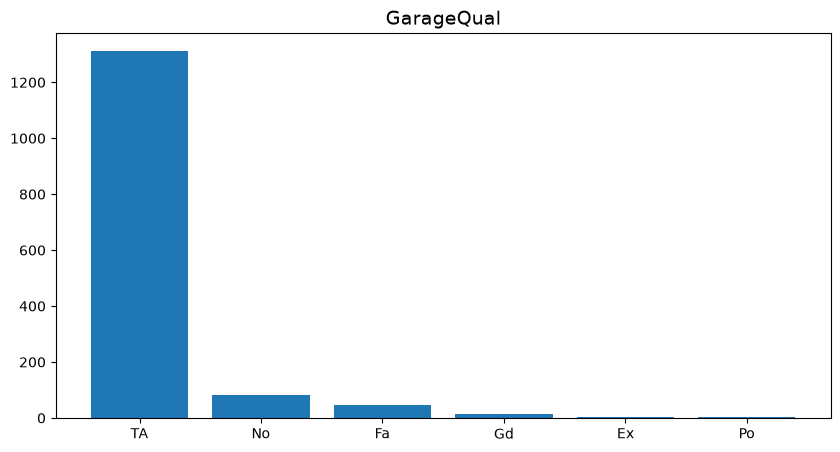

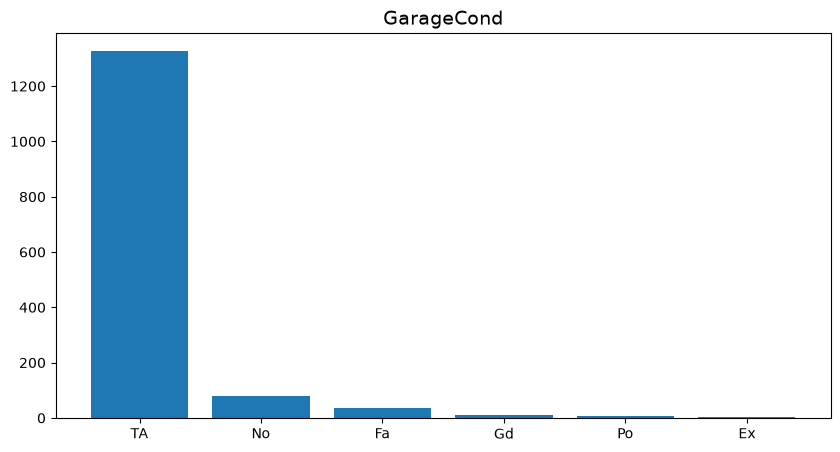

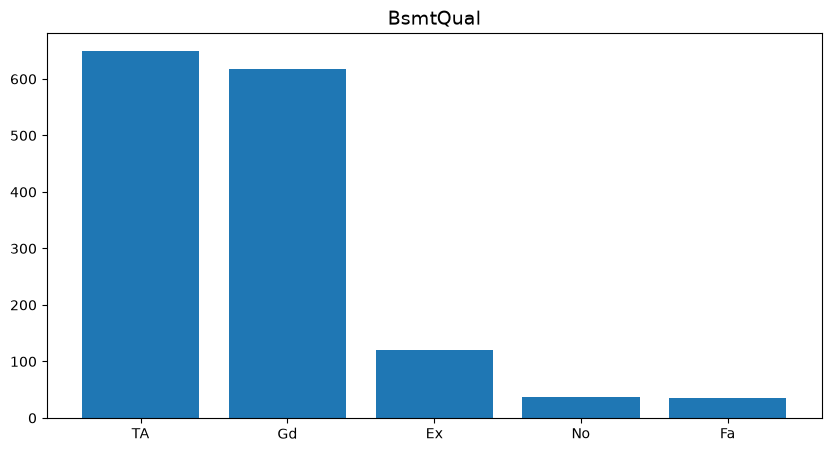

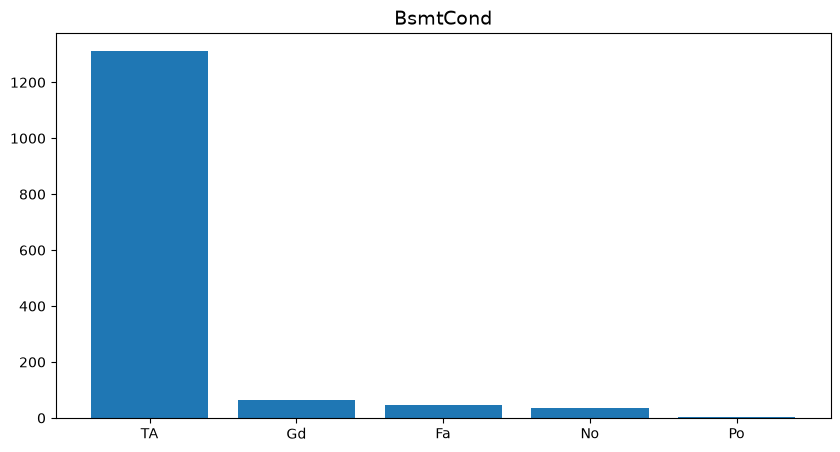

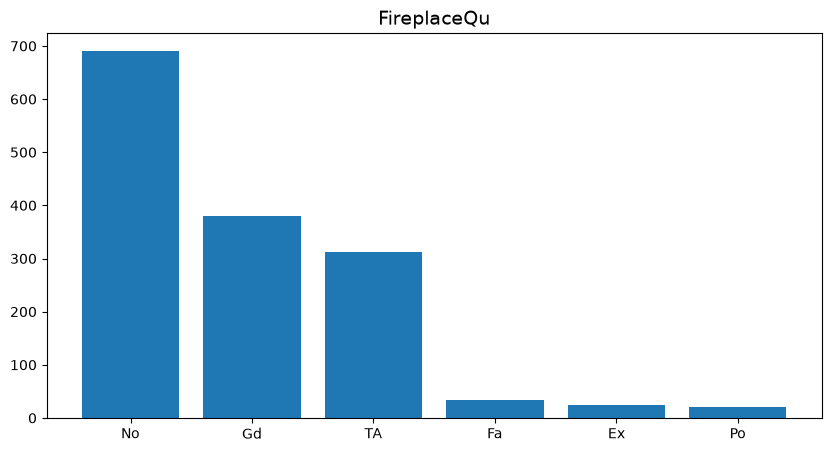

In [121]:
# Lets put all the columns univariate analysis
for col in columns:
  plt.bar(df[col].value_counts().index, df[col].value_counts())
  plt.title(col)
  plt.show()

In [122]:
df.groupby('OverallCond')['SalePrice'].median()

OverallCond
1     61000.0
2     85000.0
3     89500.0
4    115000.0
5    185000.0
6    142750.0
7    145000.0
8    142500.0
9    176200.0
Name: SalePrice, dtype: float64

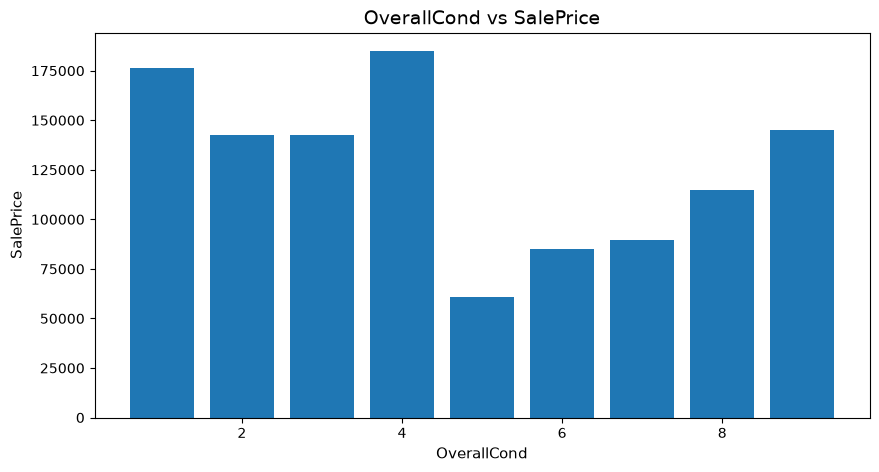

In [123]:
plt.bar(df.OverallCond.value_counts().index, df.groupby('OverallCond')['SalePrice'].median())
plt.title('OverallCond vs SalePrice')
plt.xlabel('OverallCond')
plt.ylabel('SalePrice')
plt.show()

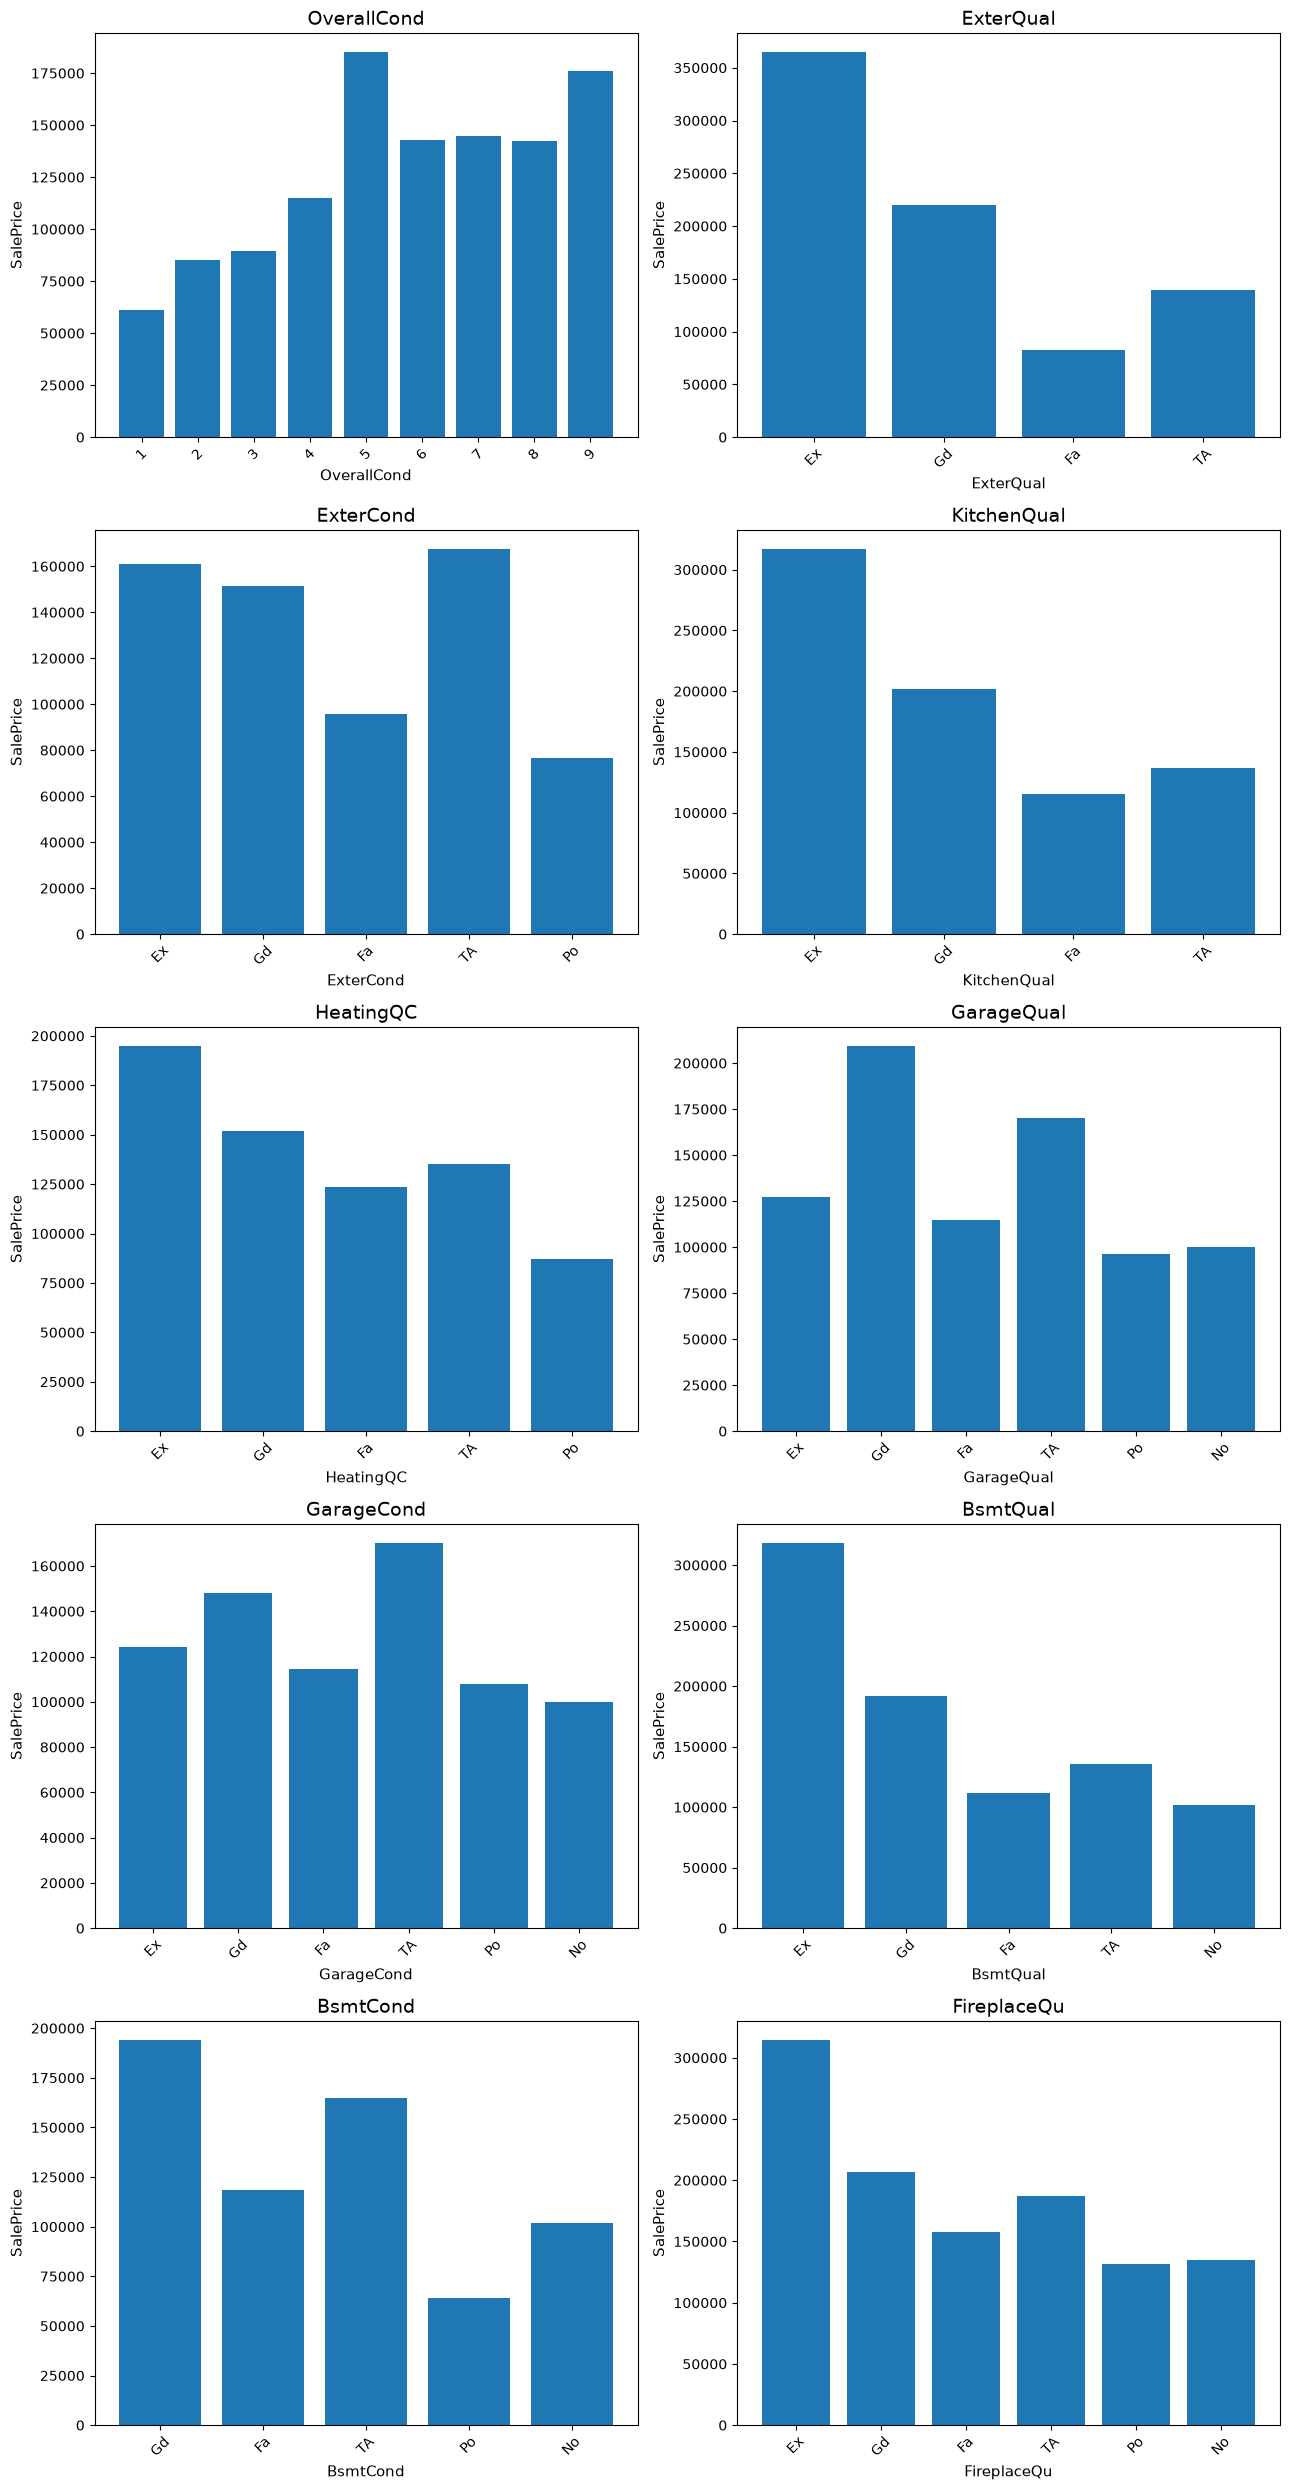

In [124]:
# for all columns Bivaraite analysis with SalePrice, put all in single plot and subplot them
no_of_plots = len(columns)
no_of_rows = 5
no_of_cols = 2

# set my order of index values
# [Ex > Gd > Fa > TA > Po]
qual_cond_order = ['Ex', 'Gd', 'Fa', 'TA', 'Po']

# make r

plt.figure(figsize=(13,25))
for i, col in enumerate(columns):
  plt.subplot(no_of_rows, no_of_cols, i+1)

  median_prices = df.groupby(col)['SalePrice'].median()

  if col == 'OverallCond':
    # Numerical categories, sort by index value
    sorted_median_prices = median_prices.sort_index()
  else:
    # Categorical string values, apply custom order
    current_categories = median_prices.index.tolist()

    # Build a custom order for plotting
    # Start with known quality order, then add any remaining categories (like 'No')
    custom_plot_order = [cat for cat in qual_cond_order if cat in current_categories]
    remaining_categories = [cat for cat in current_categories if cat not in qual_cond_order]

    # Append remaining categories (e.g., 'No') to the end of the desired order
    custom_plot_order.extend(remaining_categories)

    sorted_median_prices = median_prices.reindex(custom_plot_order).dropna()

  plt.bar(sorted_median_prices.index.astype(str), sorted_median_prices.values)
  plt.title(col)
  plt.xlabel(col)
  plt.ylabel('SalePrice')
  plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Observation Cell :



### Observations on Quality and Condition Analysis

Based on the analysis of various quality and condition features in relation to `SalePrice`:

*   **General Expectation vs. Observed Trends:** While it's generally expected that higher quality or better condition ratings would consistently lead to higher median `SalePrice`, the plots reveal more nuanced and sometimes non-monotonic relationships across different features.

*   **`OverallCond` (Overall Condition):** This feature displays a complex, non-monotonic relationship with `SalePrice`. The median price does not consistently increase with higher `OverallCond` ratings, indicating that other factors or specific condition thresholds might be at play, or that the market values certain condition levels disproportionately.

*   **Stronger Positive Trends (e.g., `ExterQual`, `KitchenQual`, `BsmtQual`):** Features like `ExterQual` (Exterior Quality), `KitchenQual` (Kitchen Quality), and `BsmtQual` (Basement Quality) generally show a more consistent positive correlation. Homes with 'Excellent' (Ex) ratings for these tend to have significantly higher median sale prices compared to 'Good' (Gd), 'Typical/Average' (TA), or 'Fair' (Fa) ratings. These visible quality aspects appear to be highly valued.

*   **Features with Non-Monotonicities or Deviations:**
    *   **`ExterCond` (Exterior Condition):** While 'Excellent' (Ex) is highest, 'Typical/Average' (TA) often shows a median `SalePrice` comparable to or even higher than 'Good' (Gd) or 'Fair' (Fa), suggesting that a basic, acceptable exterior condition might be sufficient for many buyers, or that the 'Good' category in this dataset doesn't translate to a proportionally higher price.
    *   **`HeatingQC` (Heating Quality and Condition):** Generally, 'Excellent' (Ex) leads, but the distinction between 'Good' (Gd) and 'Typical/Average' (TA) can be less pronounced or even inverted.
    *   **`GarageQual` and `GarageCond` (Garage Quality/Condition):** Similar to exterior condition, the highest quality (Ex) generally leads, but 'Good' (Gd) and 'Typical/Average' (TA) can show varying relationships, sometimes with 'Good' being less than 'Excellent' but 'Typical/Average' not always strictly lower than 'Good'.
    *   **`BsmtCond` (Basement Condition):** This can also show non-linearities, where 'Typical/Average' (TA) might sometimes have a higher median `SalePrice` than 'Good' (Gd), indicating a less strict hierarchy in buyer valuation for basement condition once a certain acceptable level is met.
    *   **`FireplaceQu` (Fireplace Quality):** The values are not always perfectly ordered from 'Excellent' down to 'Poor', with some inversions or close median prices between categories.

*   **'No' Category Effect:** For features that can be absent (e.g., `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `FireplaceQu`), the 'No' category (absence of the feature) consistently corresponds to a lower median `SalePrice` compared to properties where the feature is present, even at lower quality levels. This reinforces the value of having these amenities.

In conclusion, while quality and condition are undeniably important factors influencing `SalePrice`, their relationship is not always a simple, monotonically increasing one. Some features like `ExterQual` and `KitchenQual` show clear tiers, while others like `OverallCond` and `ExterCond` exhibit more complex patterns. This suggests that buyers weigh different quality and condition aspects differently, and an 'acceptable' or 'typical/average' rating for some features might satisfy most buyers without commanding a significantly higher premium for 'good' or 'excellent' ratings.

### Plotting Age, Renovation, and Time Effects

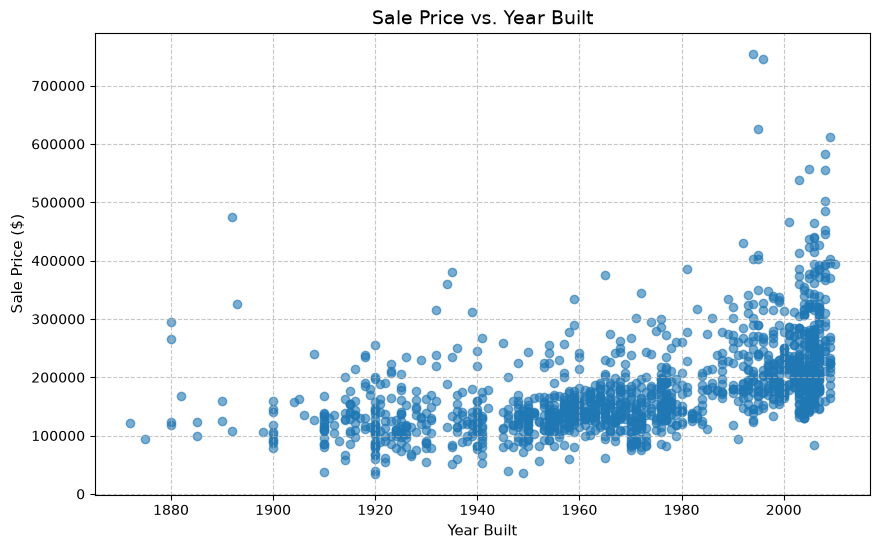

In [125]:
# 1. Do newer homes generally sell for more?
# Scatter plot of YearBuilt versus SalePrice
plt.figure(figsize=(10, 6))
plt.scatter(df['YearBuilt'], df['SalePrice'], alpha=0.6)
plt.title('Sale Price vs. Year Built')
plt.xlabel('Year Built')
plt.ylabel('Sale Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Text(0, 0.5, 'Average Sale Price ($)')

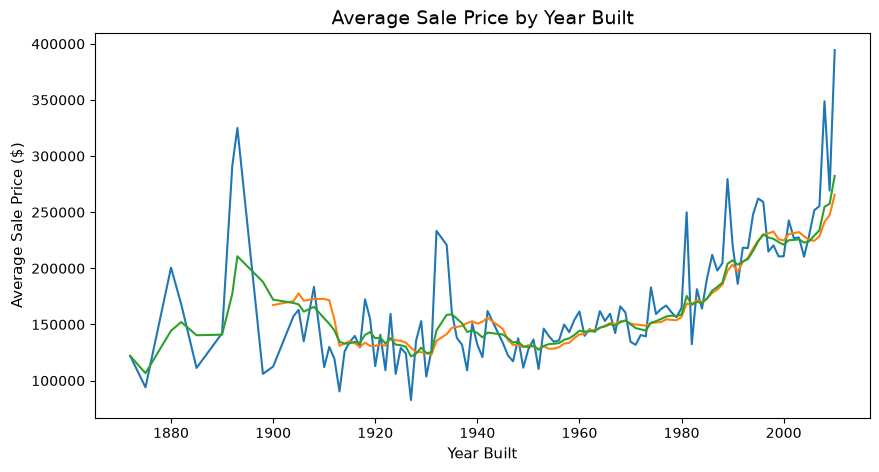

In [126]:
# group by year to sale price
df.groupby('YearBuilt')['SalePrice'].mean().plot()
plt.title('Average Sale Price by Year Built')
plt.xlabel('Year Built')
plt.ylabel('Average Sale Price ($)')

# trend line
# moving average
df.groupby('YearBuilt')['SalePrice'].mean().rolling(10).mean().plot()
plt.title('Average Sale Price by Year Built')
plt.xlabel('Year Built')
plt.ylabel('Average Sale Price ($)')

# exponential smooth curve
df.groupby('YearBuilt')['SalePrice'].mean().ewm(span=10).mean().plot()
plt.title('Average Sale Price by Year Built')
plt.xlabel('Year Built')
plt.ylabel('Average Sale Price ($)')

In [127]:
x = df.groupby('YearBuilt')['SalePrice'].mean().reset_index()
x['roll_mean'] = x['SalePrice'].rolling(10).mean()
x['ewm_mean'] = x['SalePrice'].ewm(span=10).mean()
x

,YearBuilt,SalePrice,roll_mean,ewm_mean
0,1872,122000.000000,NaN,122000.000000
1,1875,94000.000000,NaN,106600.000000
2,1880,200619.750000,NaN,144395.314784
3,1882,168000.000000,NaN,152172.006869
4,1885,111250.000000,NaN,140424.411673
5,1890,142200.000000,NaN,140885.593294
6,1892,291250.000000,NaN,177117.375027
7,1893,325000.000000,NaN,210761.384895
8,1898,106000.000000,NaN,187968.973589
9,1900,112492.600000,167281.235000,172114.696006


In [128]:
df.YearRemodAdd.value_counts()

YearRemodAdd
1950    178
2006     97
2007     76
2005     73
2004     62
2000     55
2003     51
2002     48
2008     40
1996     36
1998     36
1995     31
1976     30
1999     30
1970     26
1997     25
1977     25
2009     23
1994     22
2001     21
1972     20
1965     19
1993     19
1959     18
1971     18
1968     17
1992     17
1978     16
1990     15
1966     15
1958     15
1962     14
1969     14
1991     14
1954     14
1963     13
1960     12
1967     12
1980     12
1973     11
1964     11
1989     11
1987     10
1953     10
1956     10
1979     10
1975     10
1955      9
1985      9
1988      9
1957      9
1981      8
1961      8
1982      7
1984      7
1974      7
2010      6
1983      5
1952      5
1986      5
1951      4
Name: count, dtype: int64

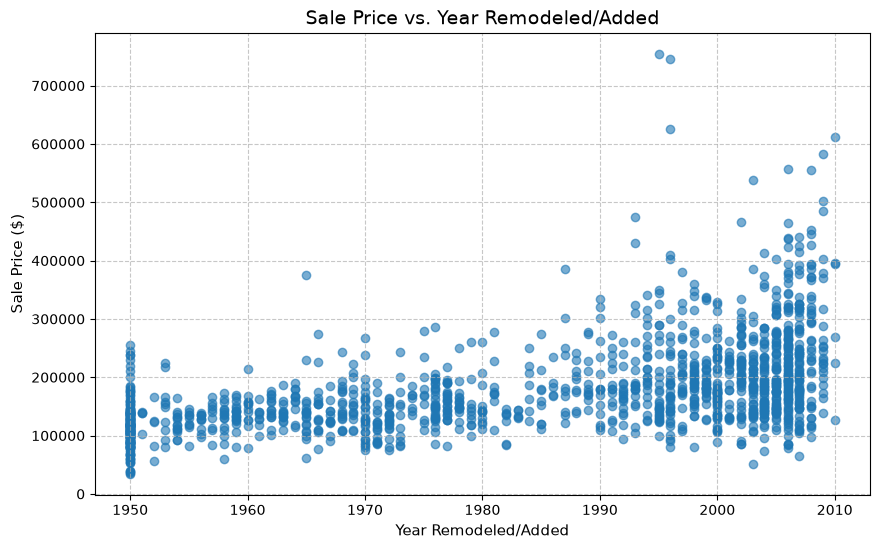

In [129]:
# 2. Is renovation year related to a higher price?
# Scatter plot of YearRemodAdd versus SalePrice
plt.figure(figsize=(10, 6))
plt.scatter(df['YearRemodAdd'], df['SalePrice'], alpha=0.6)
plt.title('Sale Price vs. Year Remodeled/Added')
plt.xlabel('Year Remodeled/Added')
plt.ylabel('Sale Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Text(0, 0.5, 'Average Sale Price ($)')

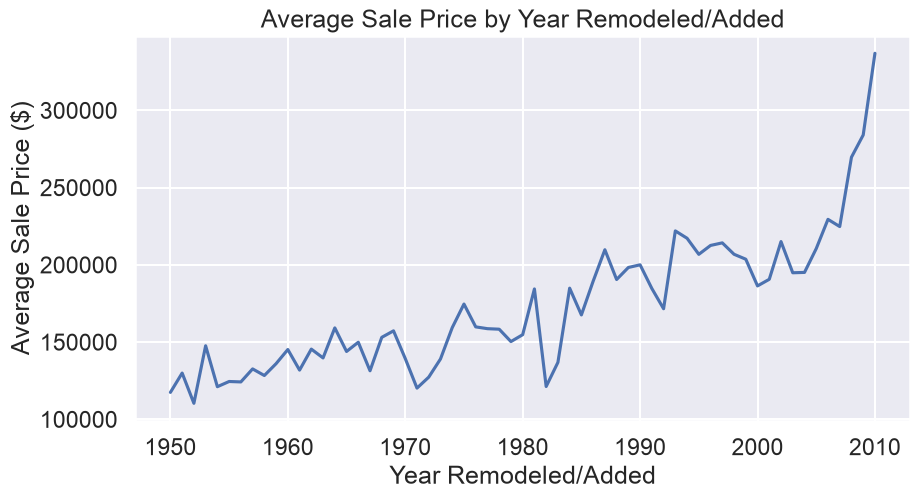

In [142]:
df.groupby('YearRemodAdd')['SalePrice'].mean().plot()
plt.title('Average Sale Price by Year Remodeled/Added')
plt.xlabel('Year Remodeled/Added')
plt.ylabel('Average Sale Price ($)')

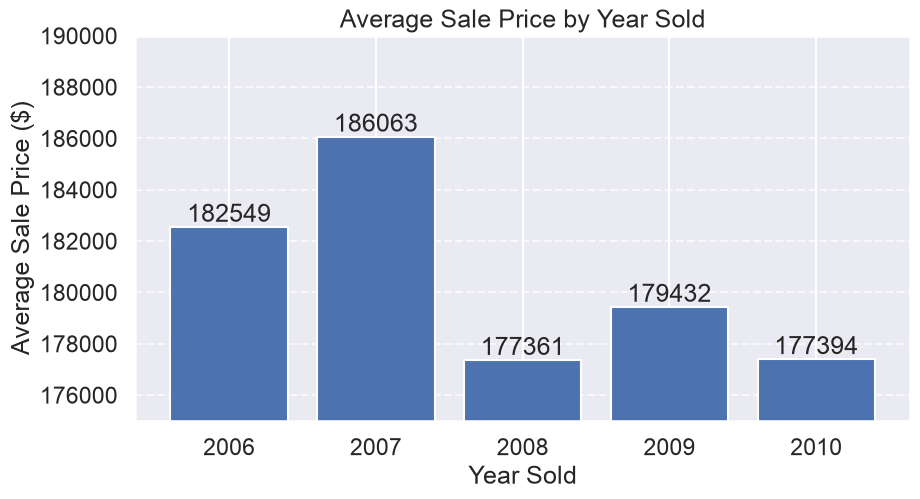

In [143]:
# 3. Does sale year show a broad market shift in price?
# Bar chart of average SalePrice by YrSold
plt.figure(figsize=(10, 5))

# plot the annotated values
bars = plt.bar(df.groupby('YrSold')['SalePrice'].mean().index, df.groupby('YrSold')['SalePrice'].mean())
plt.bar_label(bars)
plt.title('Average Sale Price by Year Sold')
plt.xlabel('Year Sold')
plt.ylabel('Average Sale Price ($)')


plt.ylim(175000,190000)

#set x ticks to be a,b,c,d,e
#  plt.xticks(['a','b','c','d','e'], rotation=0)
plt.grid(axis='y', linestyle ='--', alpha=0.7)
plt.show()

In [144]:
df['YrSold'].value_counts()

YrSold
2009    338
2007    329
2006    314
2008    304
2010    175
Name: count, dtype: int64

In [133]:
# 4. Does the month of sale show any recurring pattern?
# Bar chart of average SalePrice by MoSold
# Order months for better visualization
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg_price = df.groupby('MoSold')['SalePrice'].median().sort_values(ascending=False).reindex(month_order)

monthly_avg_price

MoSold
Jan    151650.0
Feb    173250.0
Mar    165250.0
Apr    147000.0
May    154000.0
Jun    163000.0
Jul    165195.0
Aug    174450.0
Sep    185900.0
Oct    159000.0
Nov    173000.0
Dec    178000.0
Name: SalePrice, dtype: float64

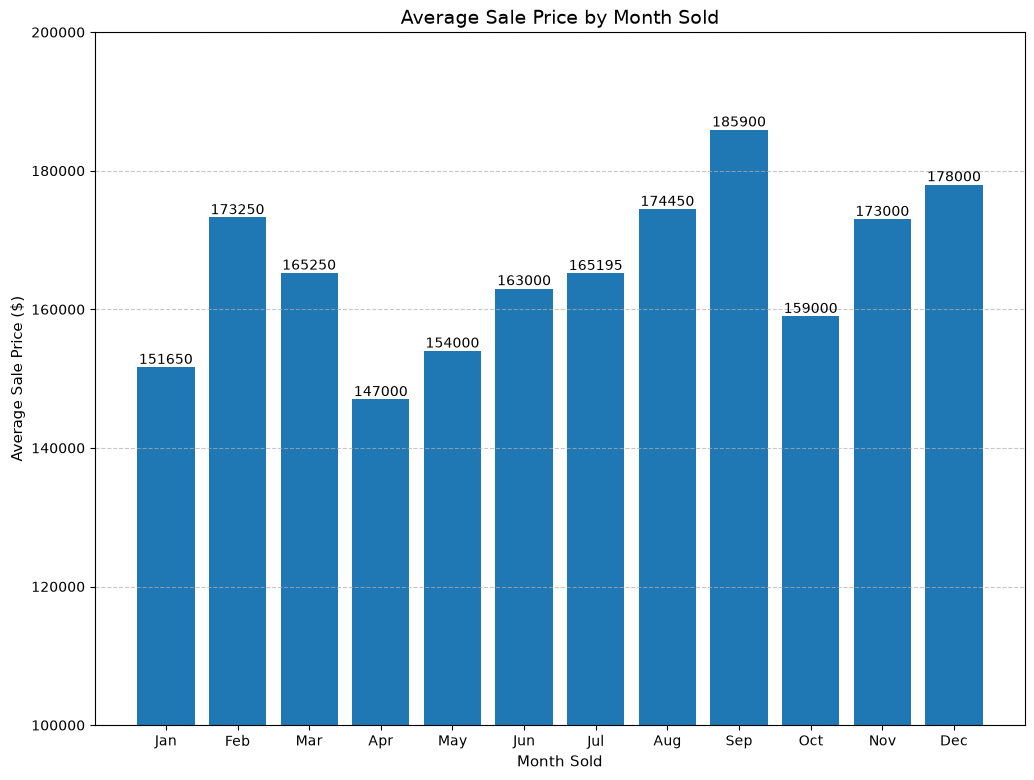

In [134]:
#plot

plt.figure(figsize=(12, 9))
bars = plt.bar(monthly_avg_price.index, monthly_avg_price)
plt.bar_label(bars)
plt.title('Average Sale Price by Month Sold')
plt.xlabel('Month Sold')
plt.ylabel('Average Sale Price ($)')
plt.ylim(100000,200000)
plt.grid(axis='y', linestyle ='--', alpha=0.7)
plt.show()

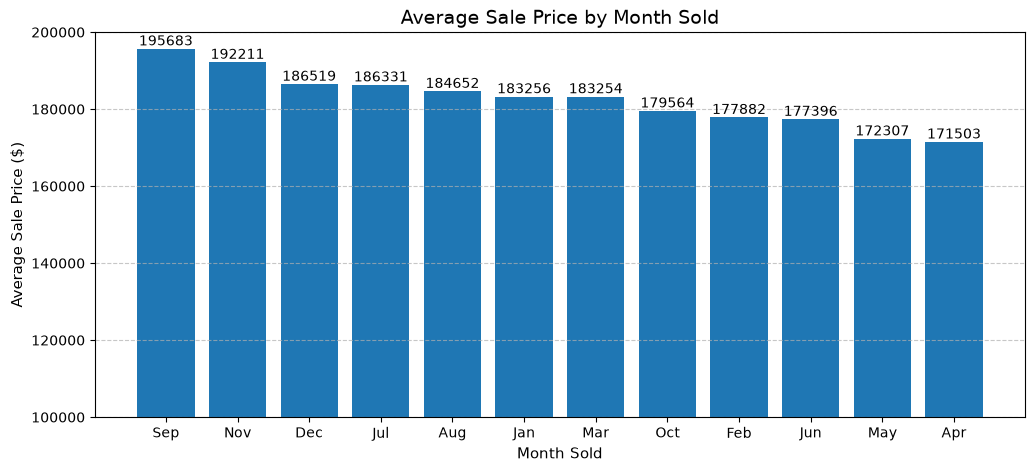

In [135]:
#plot
monthly_avg_price = df.groupby('MoSold')['SalePrice'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
bars = plt.bar(monthly_avg_price.index, monthly_avg_price)
plt.bar_label(bars)
plt.title('Average Sale Price by Month Sold')
plt.xlabel('Month Sold')
plt.ylabel('Average Sale Price ($)')
plt.ylim(100000,200000)
plt.grid(axis='y', linestyle ='--', alpha=0.7)
plt.show()

### Observations on Age, Renovation, and Time Effects Analysis

Based on the analysis of age, renovation, and time-related features:

*   **`YearBuilt` vs. `SalePrice`:** A strong positive correlation is observed. Generally, newer homes command higher sale prices. The scatter plot and the smoothed trend lines clearly illustrate a consistent increase in average sale price with more recent construction years, especially from the mid-20th century onwards, although some older properties (presumably well-maintained or unique) can still be valuable. There are some historical dips, but the long-term trend is upward.
*   **`YearRemodAdd` vs. `SalePrice`:** Similar to `YearBuilt`, a clear positive relationship exists. Properties that have been more recently remodeled or added to tend to sell for higher prices. This trend is particularly evident in recent decades, highlighting the value added by modern renovations and updates. Renovations appear to effectively mitigate the depreciation associated with older construction.
*   **`YrSold` vs. `SalePrice`:** The bar chart of average `SalePrice` by `YrSold` reveals short-term market fluctuations rather than a consistent broad market shift during the observed period (2006-2010). There was a peak in 2007, followed by a dip in 2008, a slight recovery in 2009, and another decline in 2010. This suggests sensitivity to economic conditions or local market dynamics within this five-year window.
*   **`MoSold` vs. `SalePrice`:** A distinct seasonal pattern emerges from the bar chart. Months like September, November, and December show the highest average sale prices, while April and May tend to have the lowest. This could be attributed to various factors such as school calendars, holiday seasons, or weather conditions influencing buyer activity and market demand.
*   **Older Homes and Price:** While the general trend favors newer and recently renovated homes, the analysis of `YearBuilt` and `YearRemodAdd` confirms that older homes that have undergone recent remodeling or additions can achieve competitive prices. The 'Age, Renovation, and Time Effects' are not simply about the initial build year but also the ongoing investment in the property.
*   **Renovation Offsetting Age:** The strong correlation between `YearRemodAdd` and `SalePrice` implies that strategic renovations are a significant factor in maintaining or increasing a property's value, allowing older homes to compete effectively with newer constructions.

## Age, Renovation, and Time Effects

Age matters in property analysis. A home may be old, but renovated homes can still command strong prices.

### Features to examine

- `YearBuilt`
- `YearRemodAdd`
- `YrSold`
- `MoSold`

### Questions for analysis

1. Do newer homes generally sell for more?  
   **Hint:** Use a **scatter plot** of `YearBuilt` versus `SalePrice`.

2. Is renovation year related to a higher price?  
   **Hint:** Compare `YearRemodAdd` with `SalePrice` using a **scatter plot**.

3. Does sale year show a broad market shift in price?  
   **Hint:** Use a **line plot** or **bar chart** of average `SalePrice` by `YrSold`.

4. Does the month of sale show any recurring pattern?  
   **Hint:** Use a **bar chart** of average `SalePrice` by `MoSold`.

5. Do older homes always sell for less?  
   **Hint:** Use grouped visuals instead of assuming a straight-line effect.

6. Can renovation appear to offset age in some cases?  
   **Hint:** Compare age-related patterns against quality or condition visuals.


## Relationships and Outliers

This section brings together the most important relationships seen so far and checks for unusual values that may affect interpretation.

### Questions for analysis

1. Which numerical variables appear most strongly related to `SalePrice`?  
   **Hint:** Use several **scatter plots** in a **subplot layout**.

2. Which relationship looks most linear?  
   **Hint:** Compare `GrLivArea`, `TotalBsmtSF`, `GarageArea`, and `LotArea` against price.

3. Are there signs of non-linear behavior or diminishing returns?  
   **Hint:** Look at the shape of the scatter cloud, especially at higher values.

4. Which variables show obvious outliers?  
   **Hint:** Use **box plots** for the selected variables.

5. Are there homes that look unusual but still valid?  
   **Hint:** Combine scatter plots with box plots before deciding whether a value is suspicious.

6. Which outliers should be treated as rare market cases rather than data errors?  
   **Hint:** Use context from neighborhood, quality, and size features before concluding.


In [145]:
import seaborn as sns
sns.set_theme(style="darkgrid", context="talk")
#

In [146]:
## Relationships and Outliers
# 1. Which numerical variables appear most strongly related to SalePrice?
# Hint: Use several scatter plots in a subplot layout.

num_features = df.select_dtypes(include=['int64', 'float64']).columns
num_features = num_features.drop('SalePrice')

# Calculate the correlation of each numerical feature with SalePrice
correlations = df[num_features].corrwith(df.SalePrice).sort_values(ascending=False)
print("Correlations with SalePrice:\n", correlations)

Correlations with SalePrice:
 OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
LotFrontage      0.209624
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
dtype: float64


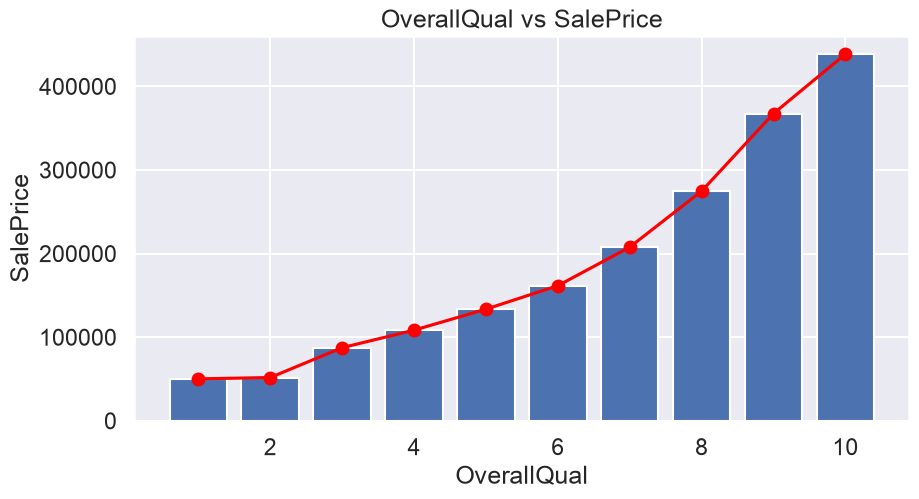

In [147]:

Bars = plt.bar(df.groupby('OverallQual')['SalePrice'].mean().index, df.groupby("OverallQual")['SalePrice'].mean())
plt.bar_label (bars)
plt.plot(df.groupby('OverallQual')['SalePrice'].mean().index, df.groupby('OverallQual')['SalePrice'].mean(), color='red', marker='o')
plt.title('OverallQual vs SalePrice')
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.show()

In [139]:
matrix_corr = df[num_features].corr()
matrix_corr

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold
LotFrontage,1.000000,0.100739,0.176561,-0.053457,0.036853,0.078686,0.105010,0.076670,-0.009312,0.160829,0.238274,0.245181,0.042549,0.049981,0.220347,0.010514,-0.027856,0.120548,-0.012952,0.144494,0.034425,0.221396,0.044018,0.044045,0.165229,0.201473,-0.016780,0.069605,0.027366,0.023499,0.022969,0.114106,-0.059606,-0.012094
LotArea,0.100739,1.000000,0.105806,-0.005636,0.014228,0.013788,0.103321,0.214103,0.111170,-0.002618,0.260833,0.299475,0.050986,0.004779,0.263116,0.158155,0.048046,0.126031,0.014259,0.119690,-0.017784,0.190015,0.271364,-0.024947,0.154871,0.180403,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,-0.014261
OverallQual,0.176561,0.105806,1.000000,-0.091932,0.572323,0.550684,0.407252,0.239666,-0.059119,0.308159,0.537808,0.476224,0.295493,-0.030429,0.593007,0.111098,-0.040150,0.550600,0.273458,0.101676,-0.183882,0.427452,0.396765,0.547766,0.600671,0.562022,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,-0.027347
OverallCond,-0.053457,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.125694,-0.046231,0.040229,-0.136841,-0.171098,-0.144203,0.028942,0.025494,-0.079686,-0.054942,0.117821,-0.194149,-0.060769,0.012980,-0.087001,-0.057583,-0.023820,-0.324297,-0.185758,-0.151521,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,0.043950
YearBuilt,0.036853,0.014228,0.572323,-0.375983,1.000000,0.592855,0.311600,0.249503,-0.049107,0.149040,0.391452,0.281986,0.010308,-0.183784,0.199010,0.187599,-0.038162,0.468271,0.242656,-0.070651,-0.174800,0.095589,0.147716,0.825667,0.537850,0.478954,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,-0.013618
YearRemodAdd,0.078686,0.013788,0.550684,0.073741,0.592855,1.000000,0.176529,0.128451,-0.067759,0.181133,0.291066,0.240379,0.140024,-0.062419,0.287389,0.119470,-0.012337,0.439046,0.183331,-0.040581,-0.149598,0.191740,0.112581,0.642277,0.420622,0.371600,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.035743
MasVnrArea,0.105010,0.103321,0.407252,-0.125694,0.311600,0.176529,1.000000,0.261256,-0.071330,0.113862,0.360067,0.339850,0.173800,-0.068628,0.388052,0.083010,0.027403,0.272999,0.199108,0.102775,-0.038450,0.279568,0.247015,0.248546,0.361945,0.370884,0.159991,0.122528,-0.109907,0.019144,0.062248,0.011928,-0.029512,-0.008317
BsmtFinSF1,0.076670,0.214103,0.239666,-0.046231,0.249503,0.128451,0.261256,1.000000,-0.050117,-0.495251,0.522396,0.445863,-0.137079,-0.064503,0.208171,0.649212,0.067418,0.058543,0.004262,-0.107355,-0.081007,0.044316,0.260011,0.153484,0.224054,0.296970,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,0.014359
BsmtFinSF2,-0.009312,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.071330,-0.050117,1.000000,-0.209294,0.104810,0.097117,-0.099260,0.014807,-0.009640,0.158678,0.070948,-0.076444,-0.032148,-0.015728,-0.040751,-0.035227,0.046921,-0.088011,-0.038264,-0.018227,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,0.031706
BsmtUnfSF,0.160829,-0.002618,0.308159,-0.136841,0.149040,0.181133,0.113862,-0.495251,-0.209294,1.000000,0.415360,0.317987,0.004469,0.028167,0.240257,-0.422900,-0.095804,0.288886,-0.041118,0.166643,0.030086,0.250647,0.051575,0.190708,0.214175,0.183303,-0.005316,0.129005,-0.002538,0.020764,-0.012579,-0.035092,-0.023837,-0.041258


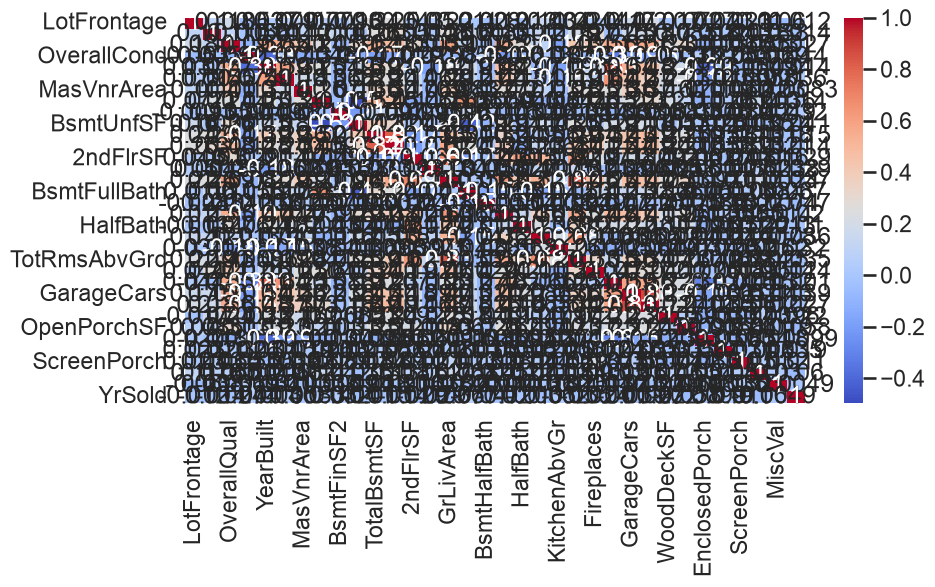

In [148]:
plt.figure(figsize=(10,5))
sns.heatmap(matrix_corr, annot=True, cmap='coolwarm',  )
plt.show()

In [141]:
# stem plot
plt.figure(figsize=(10, 6))
plt.ste m(correlations.index, correlations.values)
plt.xticks(rotation=90)
plt.title('Correlation Stem Plot with SalePrice')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.show()

SyntaxError: invalid syntax (2577540456.py, line 3)

## Relationships and Outliers

This section brings together the most important relationships seen so far and checks for unusual values that may affect interpretation.

### Questions for analysis

1. Which numerical variables appear most strongly related to `SalePrice`?  
   **Hint:** Use several **scatter plots** in a **subplot layout**.

2. Which relationship looks most linear?  
   **Hint:** Compare `GrLivArea`, `TotalBsmtSF`, `GarageArea`, and `LotArea` against price.

3. Are there signs of non-linear behavior or diminishing returns?  
   **Hint:** Look at the shape of the scatter cloud, especially at higher values.

4. Which variables show obvious outliers?  
   **Hint:** Use **box plots** for the selected variables.

5. Are there homes that look unusual but still valid?  
   **Hint:** Combine scatter plots with box plots before deciding whether a value is suspicious.

6. Which outliers should be treated as rare market cases rather than data errors?  
   **Hint:** Use context from neighborhood, quality, and size features before concluding.


## Final Visual Summary

The final output should not be a random collection of plots. It should read like a compact visual report.

### Recommended visual set for the summary figure

- `SalePrice` histogram
- `SalePrice` box plot
- top neighborhoods by count
- average `SalePrice` by `Neighborhood`
- `SalePrice` vs `GrLivArea`
- `SalePrice` by `OverallQual`

### Questions for analysis

1. Which three visuals best summarize the housing market?  
   **Hint:** Choose visuals that cover distribution, comparison, and relationship.

2. Which chart best explains why some homes sell for much more than others?  
   **Hint:** Look at quality and living area.

3. Which chart best explains location differences?  
   **Hint:** Use neighborhood-level comparisons.

4. Which chart best shows unusual cases?  
   **Hint:** Use the box plot and scatter plot together.

5. What is the strongest business message from the analysis?  
   **Hint:** Write one short conclusion for price, one for size, and one for location.


## Class Practice Tasks

These tasks should be attempted by learners after the guided walkthrough.

### Practice tasks

1. Choose one categorical variable and compare `SalePrice` across its categories.  
   **Hint:** Use a **box plot** or **bar chart** depending on the number of categories.

2. Choose one numeric size variable and study its relation to `SalePrice`.  
   **Hint:** Use a **scatter plot**.

3. Choose one quality variable and explain how price changes across levels.  
   **Hint:** Use a **box plot**.

4. Create one figure with at least four subplots from the variables studied in class.  
   **Hint:** Include a mix of **histogram**, **box plot**, **scatter plot**, and **bar chart**.

5. Write five short observations from the visuals.  
   **Hint:** Each observation should mention a variable and a clear pattern.

6. Identify one chart that should be shown to a business stakeholder first.  
   **Hint:** Select the chart with the clearest practical message.


## Notebook Close

This notebook is designed to help learners move from simple plotting to real exploratory analysis. The goal is to read the data visually, compare important groups, identify relationships, and turn the findings into a short business-style summary.
